In [234]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [236]:
def time_reader(f, time_correction=False):
    f=open(f)
    lines = f.readlines()
    time_map = {} 
    #start datetime: {end datetime: e_dt, network latency per img: nw, 
    # compute latency per imd : comp, throughput: th, batch_size: bs, num_batches: nb, 
    # total_time: e_dt - start_dt, (apply day correction if required) 
    # network latency total: nw_t, compute latency total: comp_t, 
    # flop: fp, s_per_op: s*10**9/op, nw_std: 0, comp_std: 0 } 
    dt_st=0
    dt_et=0
    last_iter = 0
    last_rank=False
    for line in lines:
        line=line.strip()
        if "startheat" in line:
            st = line.split("TIME:")[-1]
            dt_st = datetime.strptime(st, "%H:%M:%S.%f")
        if "Gloo" in line:
            # [Gloo] Rank 1 is connected to 2 peer ranks. Expected number of connected peer ranks is : 2
            rank = line.split(" ")[2]
            world = line.split(" ")[-1]
            last_rank = (rank==world)

        if "FLOP count" in line:
            #this means it was successful (probably)
            #create dict object here
            # rank 0 FLOP count: 472055808 and full time*10**9 s/op: 0.3508
            flop = line.split("count: ")[-1].split(" and ")[0]
            s_per_op = line.split("s/op: ")[-1]
            local_rank=0
            if "rank" in line:
                local_rank = line.split("rank ")[-1].split(" ")[0]

            if dt_st==0:
                dt_st=1
                dt_et=1
                time_map[dt_st]={}
            time_map[dt_st] = {"e_dt":0, "nw":0, "comp":0, "th":0, "bs":0, "nb":0, "total_time":0, "rank":int(local_rank),  
            "nw_t":0, "comp_t":0, "flop":int(flop), "s_per_op": float(s_per_op), "nw_std": 0, "comp_std": 0}
        elif "Time taken by rank:" in line:
            # Time taken by rank:1 in total(avg): 0.2246s 
            # Batch time sets raw:[[0.0576, 0.0]] 
            # Network sets raw:[[0.166, 0]] 
            # bytes sent:[] 
            # bytes recv:1605632 on 
            # avg per image: 0.0561s with std: 0.0000s 
            # network time: 0.0830s and network std: 0.0830s 
            # network time per img: 0.0207 compute time: 0.0354s 
            # compute/network ratio: 0.4264 and throughput 17.8129 img/s

            if dt_st==0:
                dt_st=1
                dt_et=1
                time_map[dt_st]={}
            nw_t = line.split("network time: ")[-1].split("s")[0]
            nw = line.split("network time per img: ")[-1].split(" ")[0]
            nw_std = line.split("network std: ")[-1].split("s")[0]
            comp_t = line.split("total(avg): ")[-1].split("s")[0]
            comp = line.split("avg per image: ")[-1].split("s")[0]
            comp_std = line.split("with std: ")[-1].split("s")[0]
            th = line.split("throughput ")[-1].split(" ")[0]
            recv = line.split("recv:")[-1].split(" ")[0]
            sent = ast.literal_eval("["+line.split("sent:[")[-1].split("] ")[0]+"]")
            if len(sent)>0:
                sent=sent[-1][-1]
            else:
                sent=0

            time_map[dt_st]["nw_t"] = float(nw_t)
            time_map[dt_st]["nw"] =  float(nw)
            time_map[dt_st]["nw_std"]=float(nw_std)
            time_map[dt_st]["comp_t"] =float(comp_t)
            time_map[dt_st]["comp"] = float(comp)
            time_map[dt_st]["comp_std"]=float(comp_std)
            time_map[dt_st]["th"]=float(th)
            time_map[dt_st]["sent"]=float(sent)
            time_map[dt_st]["recv"]=float(recv)

            block_times = ast.literal_eval(line.split("Batch time sets raw:")[-1].split("] ")[0]+"]")[-1]
            time_map[dt_st]["block_times"] = [it for it in block_times] 

            net_times = ast.literal_eval(line.split("Network sets raw:")[-1].split("] ")[0]+"]")[-1]
            time_map[dt_st]["net_times"] = [it for it in net_times] 

            #combine lists and then np.cumulative_sum to get the block boundaries
            #plot them against throttle points and heatmap maybe? 
            #start on network, end on network, if any remaining compute -> leave as is
            timing = []
            while True:
                net_p = net_times.pop(0)
                timing.append(net_p)
                if len(net_times) == 0:
                    break
                comp_p = block_times.pop(0)
                timing.append(comp_p)
            if last_rank: #corner case when rank=world, checks gloo message to verify last rank
                timing.append(block_times.pop(0))

               
            time_map[dt_st]["timing"] = np.cumulative_sum([it for it in timing])
            #even index on cumulative sum is network, odd index is compute        

        if "Sync done" in line:
            # 2026-03-17 13:59:28.033112 Sync done -> model run start
            last_iter = datetime.strptime(line.split(" ")[1].split(".")[0], "%H:%M:%S") #this is compared against heatfiles
        if "endheat" in line:
            et  = line.split("TIME:")[-1]
            if dt_st not in time_map:
                break
            dt_et = datetime.strptime(et, "%H:%M:%S.%f")
            time_map[dt_st]["e_dt"] = dt_et
    
    if dt_et==0 or dt_st==0:
        return None, None
    if time_correction:
        pass

         
    return time_map, last_iter

def heat_reader(f, last_iter=None, time_correction=False):
    f=open(f)
    lines=f.readlines()
    heat_map={}
    #{dt:{temp:t, volt:v, freq:f, throttled:t, total_volt: tv}}
    for l in range(len(lines)-2):
        line=lines[l]
        line=line.strip()
        # TIME:17:49:20
        # 32172
        # freq:frequency(48)=1400000000,throttle_flag:throttled=0x50000,voltage:volt=1.3500V,volt=1.2500V,volt=1.2500V,volt=1.2250V
        if "TIME:" in line:
            dt = datetime.strptime(line.split("TIME:")[-1], "%H:%M:%S")
            if last_iter!=None and dt < last_iter:
                continue
            temp_line = lines[l+1].strip()
            # print("here?")
            if "TIME" not in temp_line and "freq" not in temp_line:
                # cpu:average: 0.71, 0.54,,freq:frequency(48)=700000000,throttle_flag:throttled=0x50000,voltage:volt=1.2375V,volt=1.2500V,volt=1.2500V,volt=1.2250V
                # or
                # cpu:1.16, 0.61, 0.35,freq:frequency(48)=600000000,throttle_flag:throttled=0x50005,voltage:volt=1.2000V,volt=1.2500V,volt=1.2500V,volt=1.2250V

                temp = float(temp_line)/10**3
                freq_line = lines[l+2]
                if "volt" in freq_line:
                    freq = float(freq_line.split("freq:")[-1].split("=")[1].split(",")[0])*10**-9
                    throttled = (freq_line.split("throttled=")[1].split(",")[0][-1] == "0")
                    volts = [ float(v.split("volt=")[-1].split("V")[0]) for v in freq_line.split("voltage:")[-1].split(",")]
                    alt_cpu = freq_line.split("cpu:")[-1].split(",")[0] if "average" not in freq_line else freq_line.split("average: ")[-1].split(",")[0]
                    cpu = float(alt_cpu)
                    heat_map[dt]={"cpu":cpu, "temp":temp, "volt":volts[0], "freq":freq, "throttled": throttled, "total_volt":sum(volts)}
                else:
                    continue

            else:
                continue
    if time_correction:
        pass

    return heat_map

def tf_calc(w, t):
    y=0
    if w < 8:
        y = 0.157 - 0.004*t + 0.075*w
    else:
        y = 0.667 - 0.008*t + 0.023*w
    return y



[[0.08799999999999998, 0.16299999999999998, 0.23799999999999996, 0.31299999999999994, 0.388, 0.46299999999999997, 0.538, 0.563, 0.586, 0.609, 0.632, 0.655, 0.6779999999999999, 0.7010000000000001, 0.724, 0.747, 0.77, 0.7929999999999999, 0.8160000000000001, 0.839, 0.862, 0.885, 0.908, 0.931, 0.954, 0.977, 1.0, 1.0230000000000001, 1.046]]
2 [4643487744, 9869099008]
2 [4643487744, 9869099008]
3 [944111616, 10276044800, 3292430336]
3 [944111616, 10276044800, 3292430336]
3 [944111616, 10276044800, 3292430336]
3 [944111616, 10276044800, 3292430336]
4 [944111616, 6987710464, 6576668672, 4096000]
4 [944111616, 6987710464, 6576668672, 4096000]
4 [944111616, 6987710464, 6576668672, 4096000]
4 [944111616, 6987710464, 6576668672, 4096000]
5 [944111616, 0, 6987710464, 6576668672, 4096000]
5 [944111616, 0, 6987710464, 6576668672, 4096000]
5 [944111616, 0, 6987710464, 6576668672, 4096000]
5 [944111616, 0, 6987710464, 6576668672, 4096000]
6 [944111616, 0, 6987710464, 6576668672, 0, 4096000]
6 [94411161

/var/folders/hw/swljgpyn0mn_cgf1fmg8gvsr0000gn/T/ipykernel_14686/3507753976.py:333: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  bar_axs.legend()
/Users/animeshnd/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/animeshnd/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/hw/swljgpyn0mn_cgf1fmg8gvsr0000gn/T/ipykernel_14686/3507753976.py:383: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


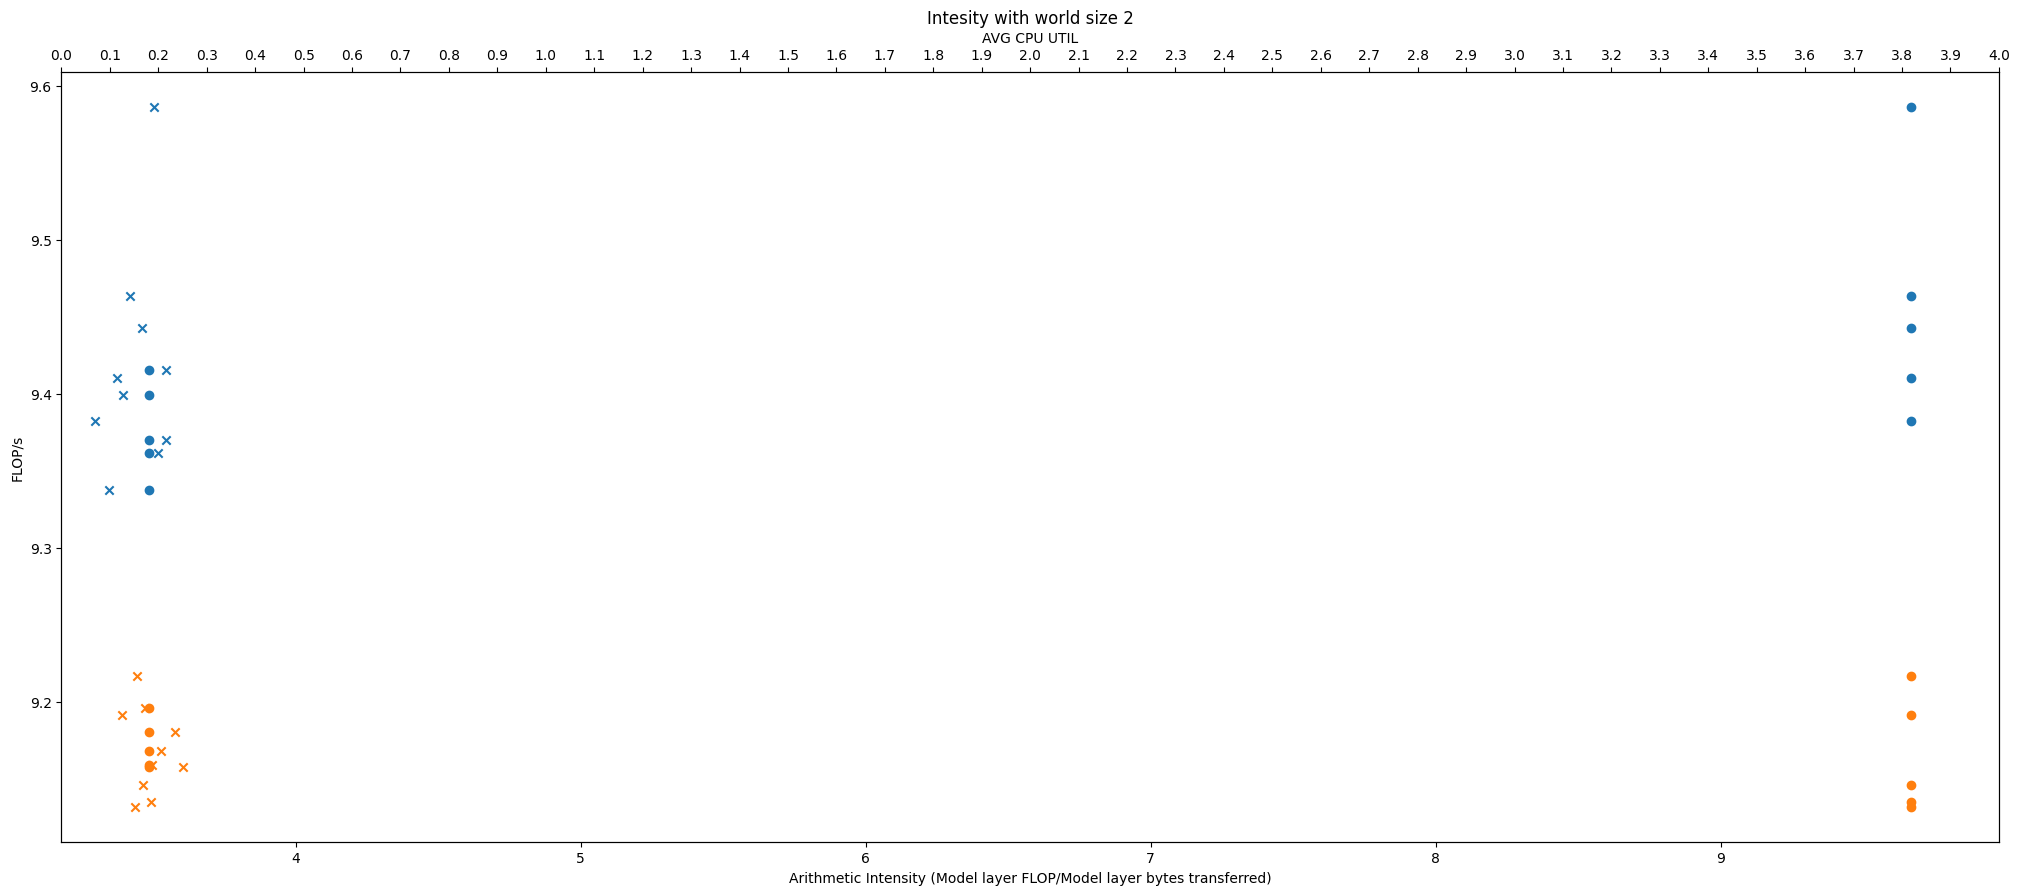

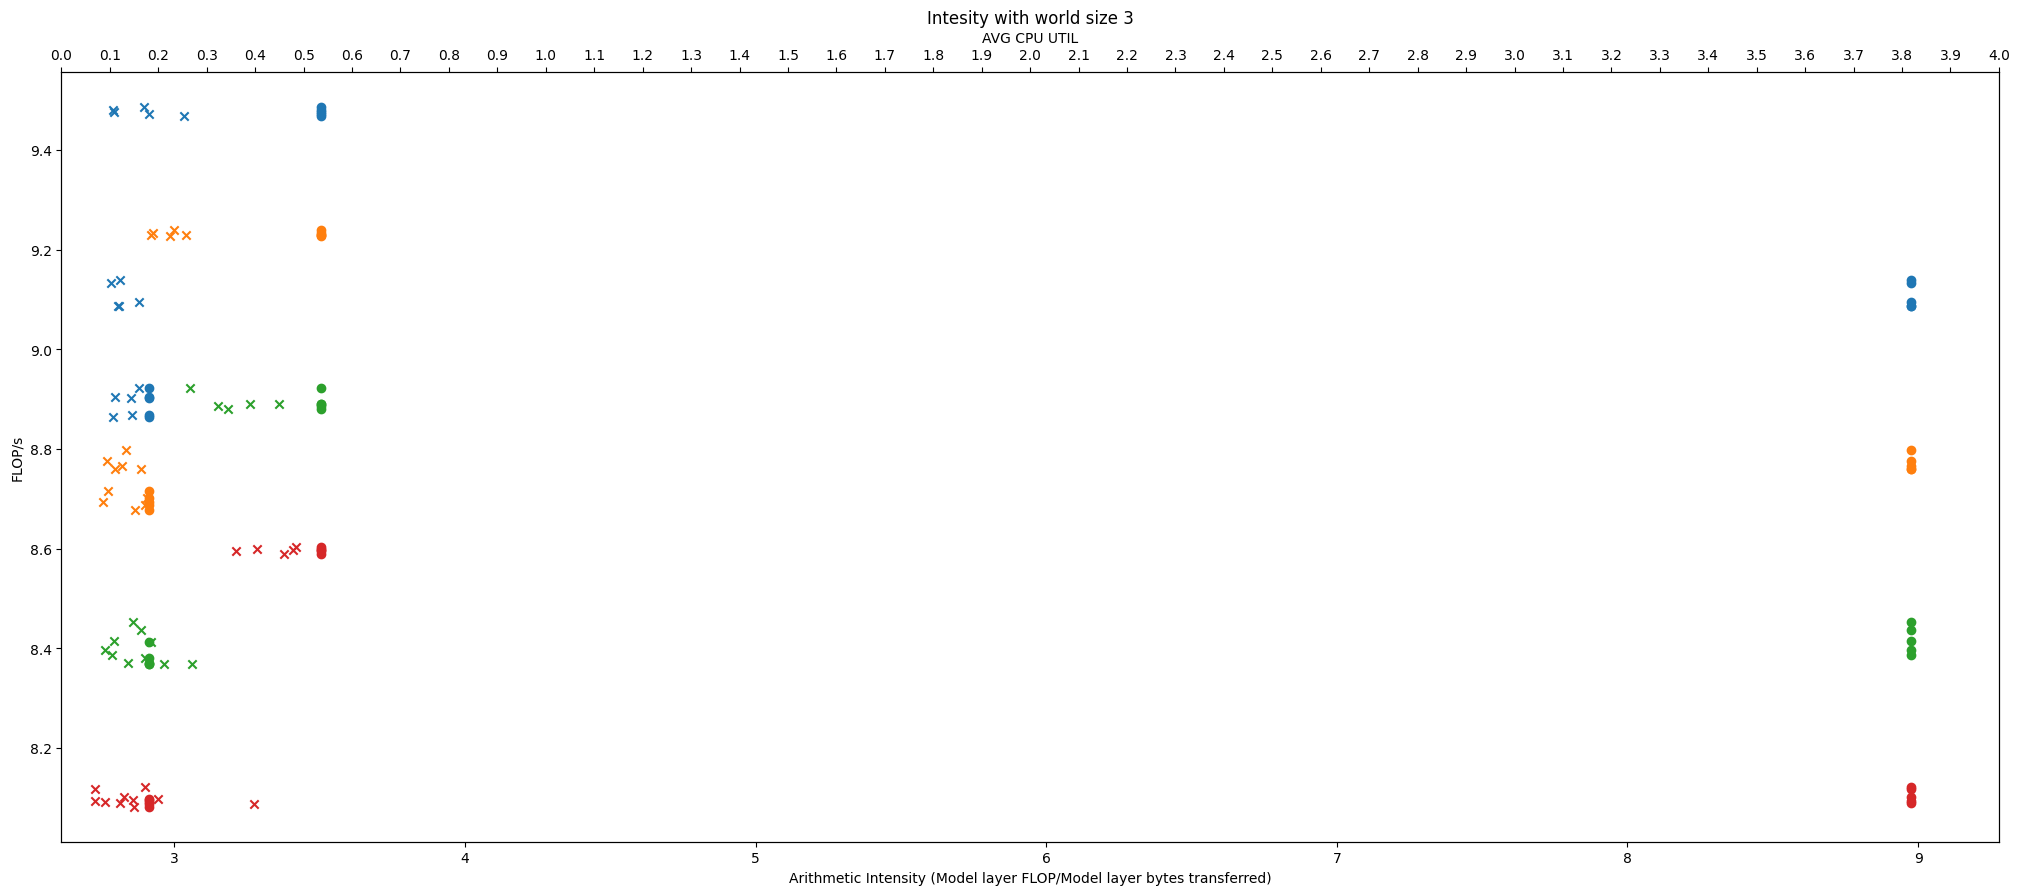

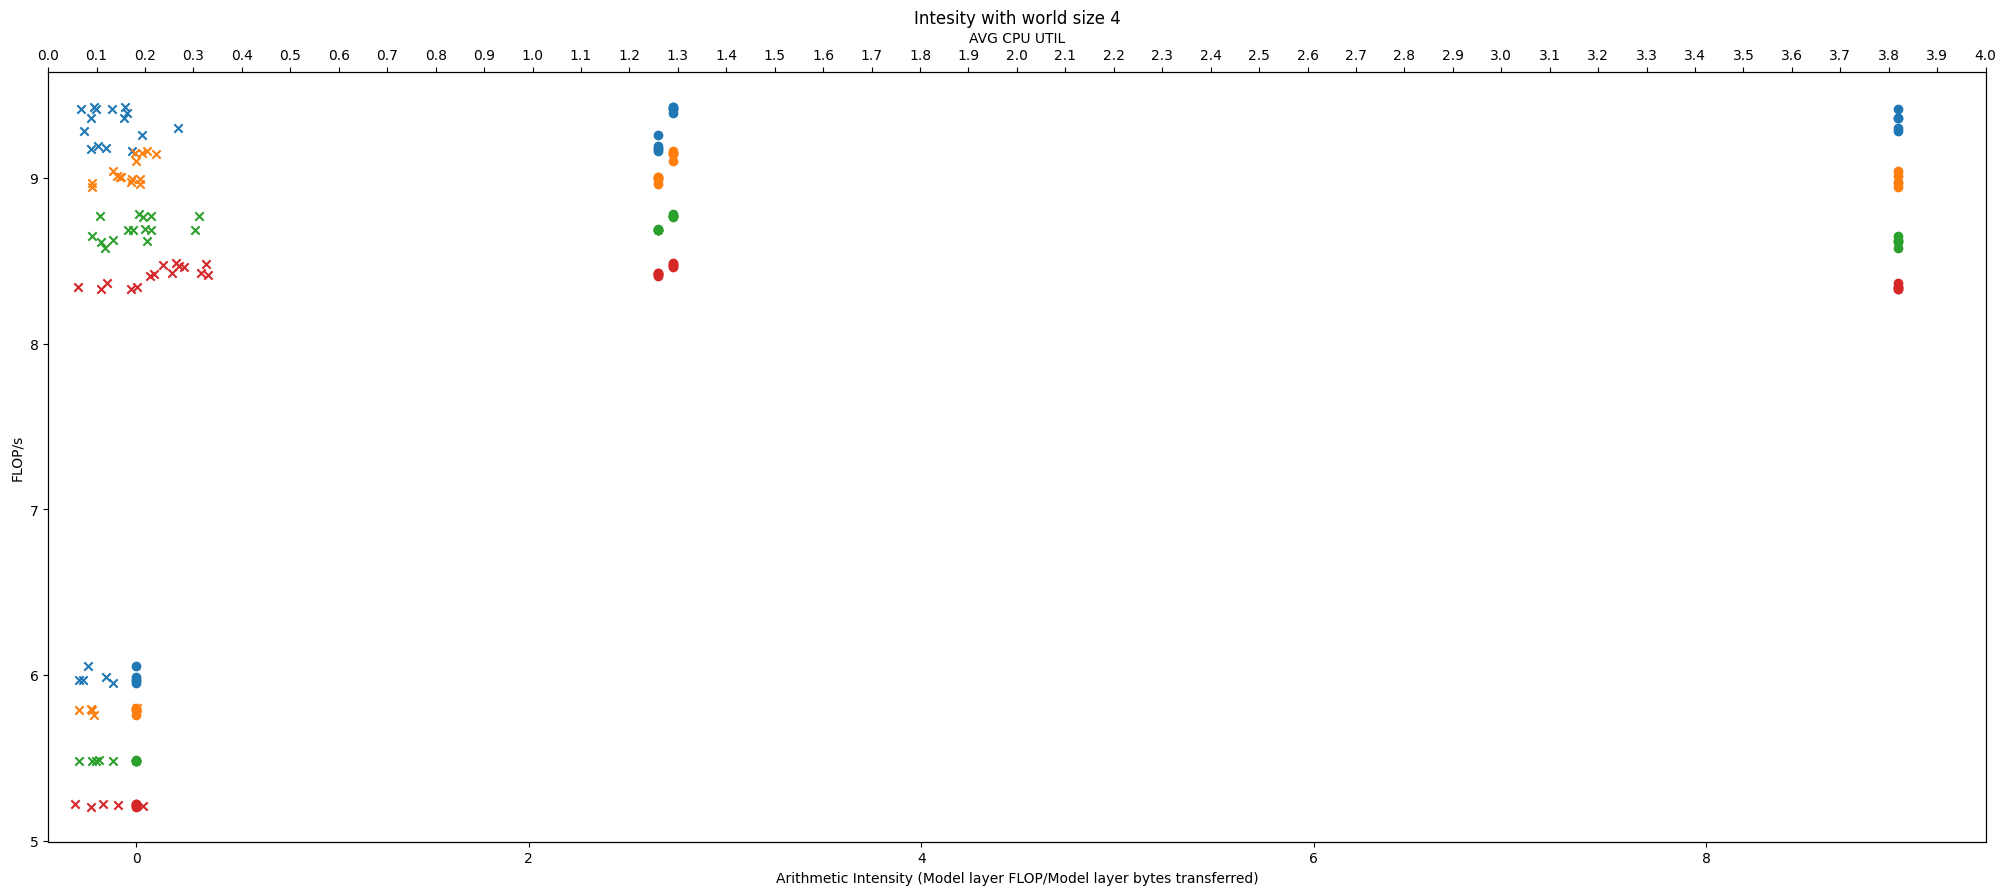

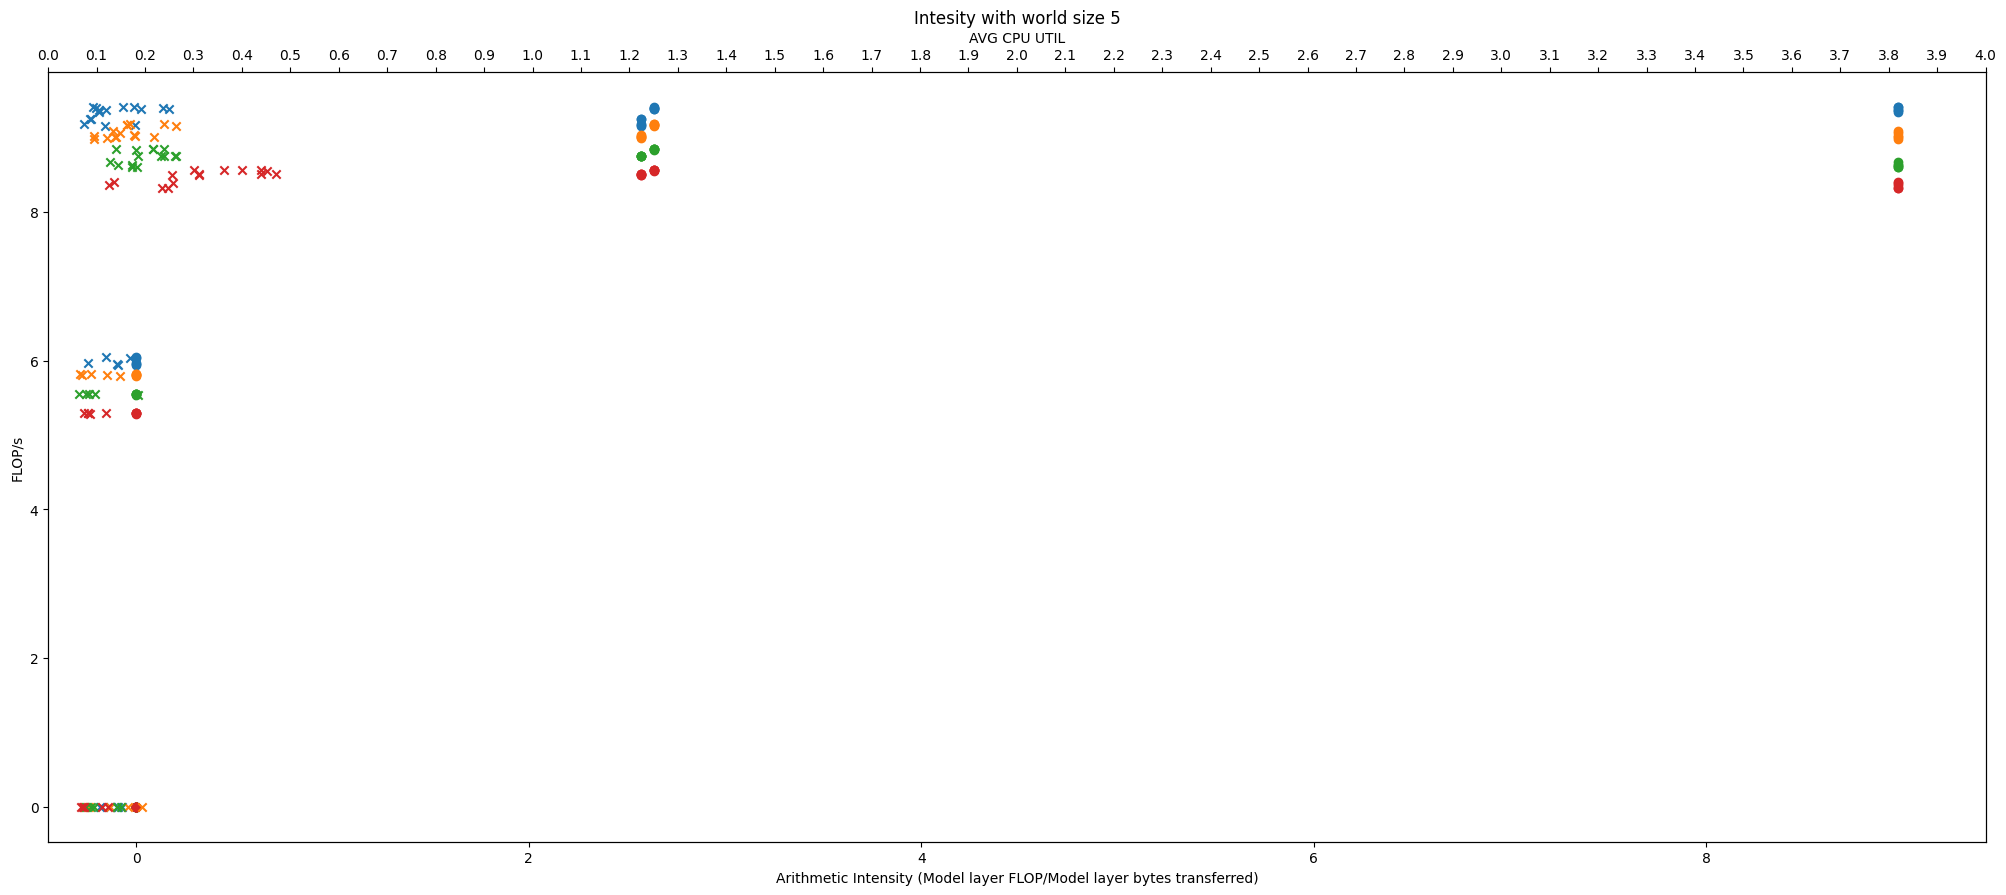

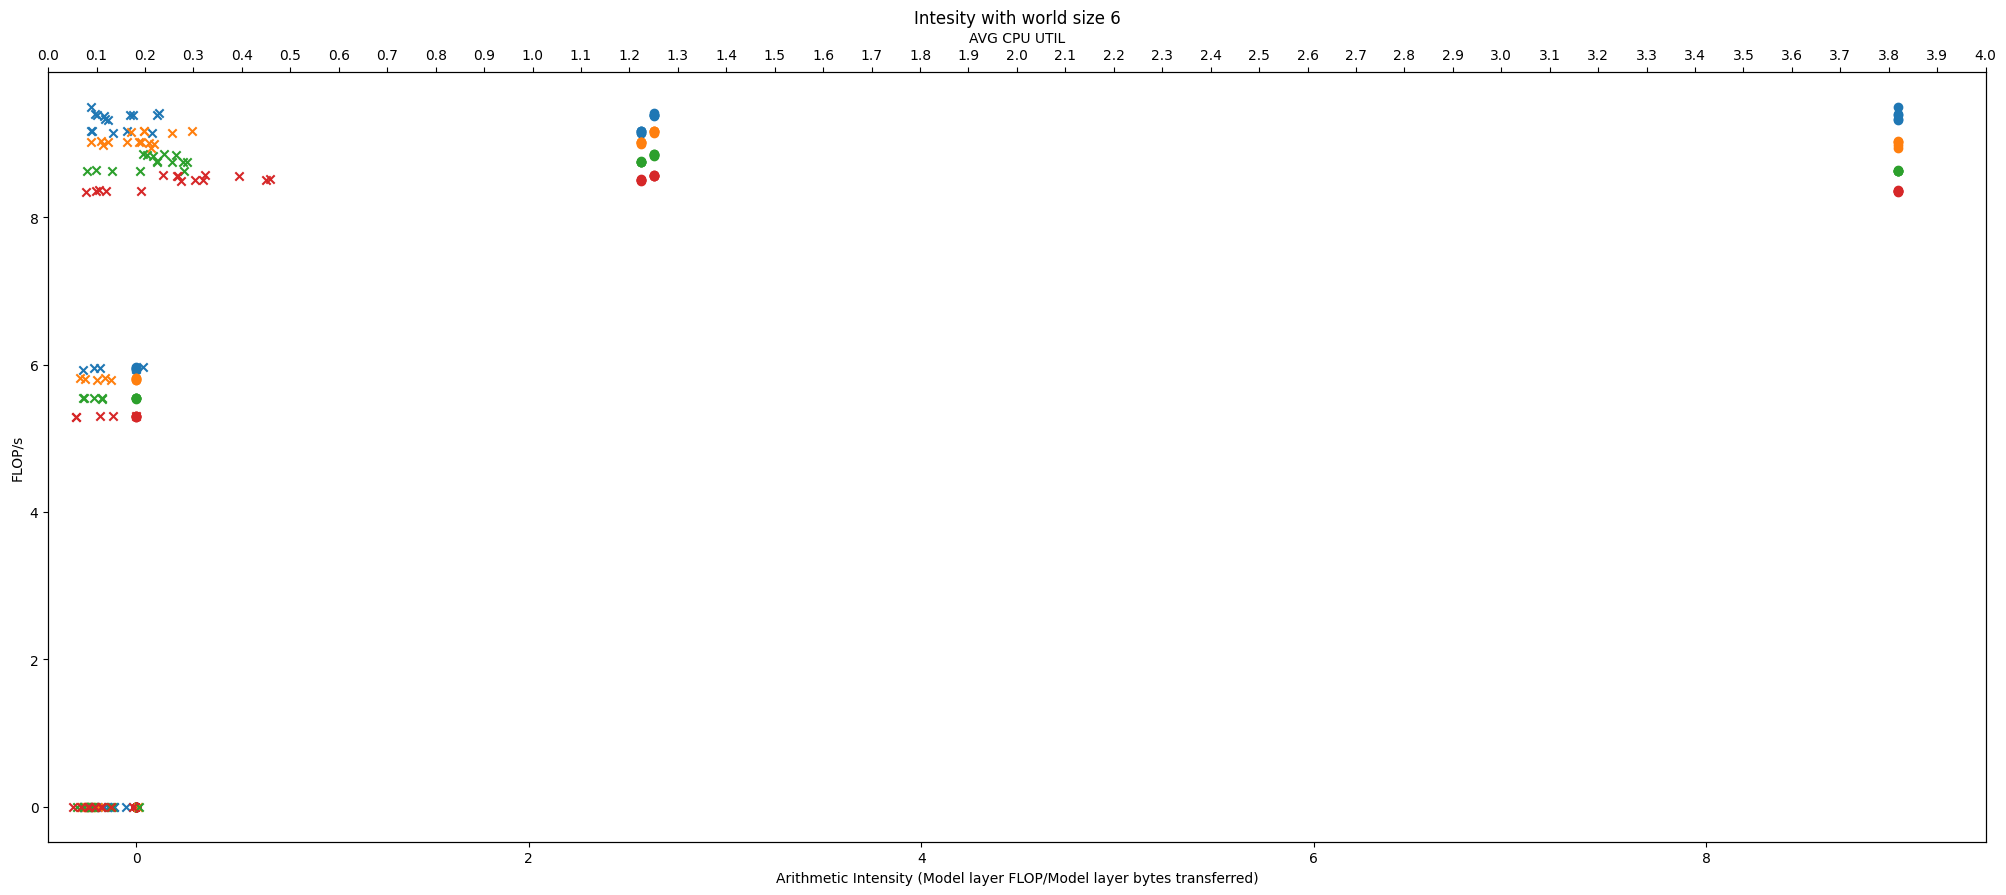

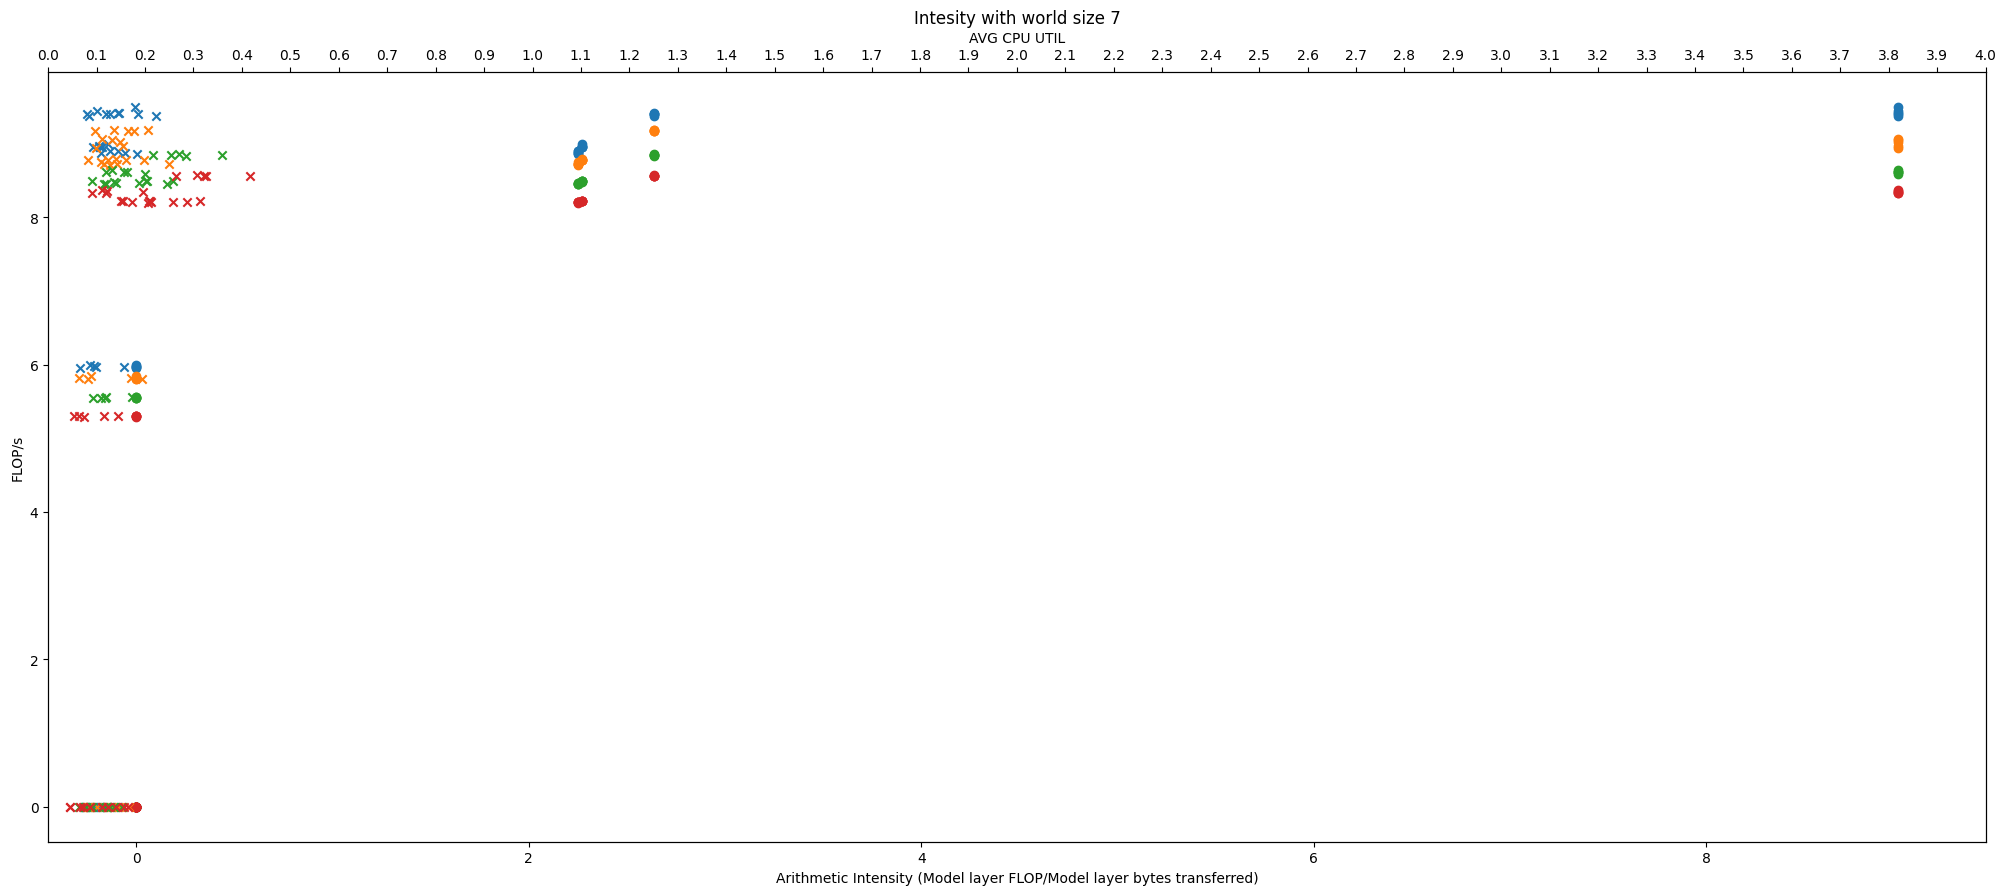

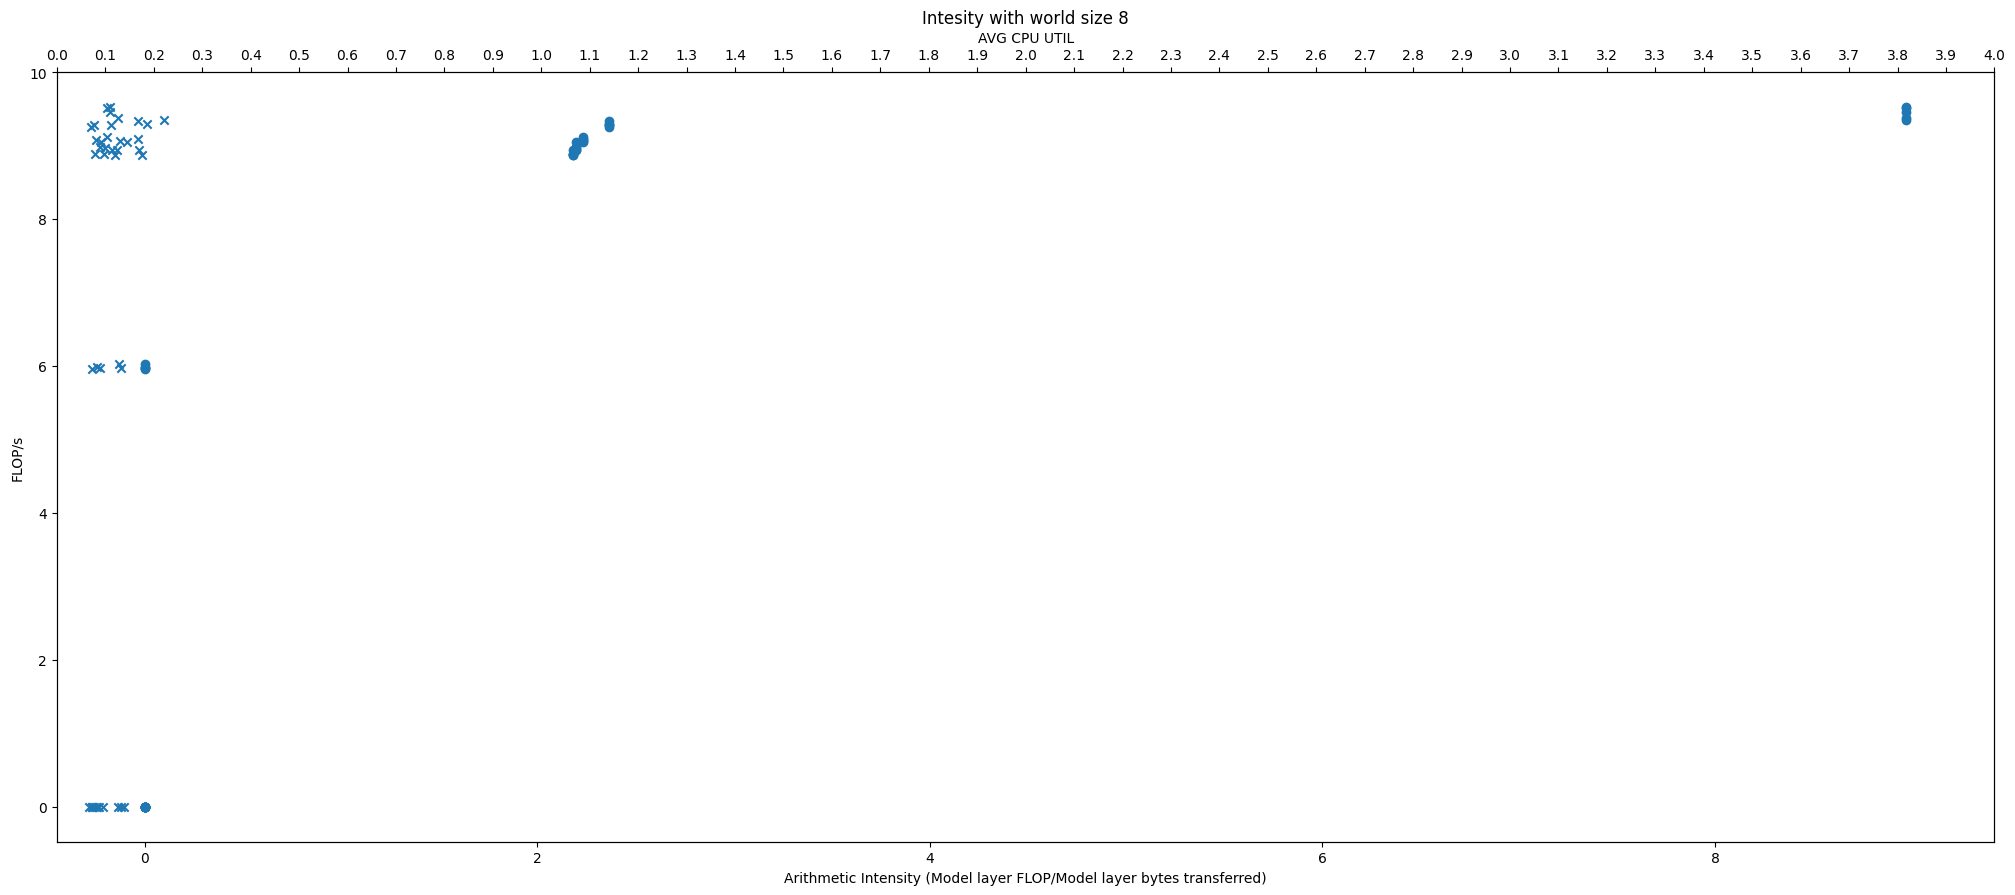

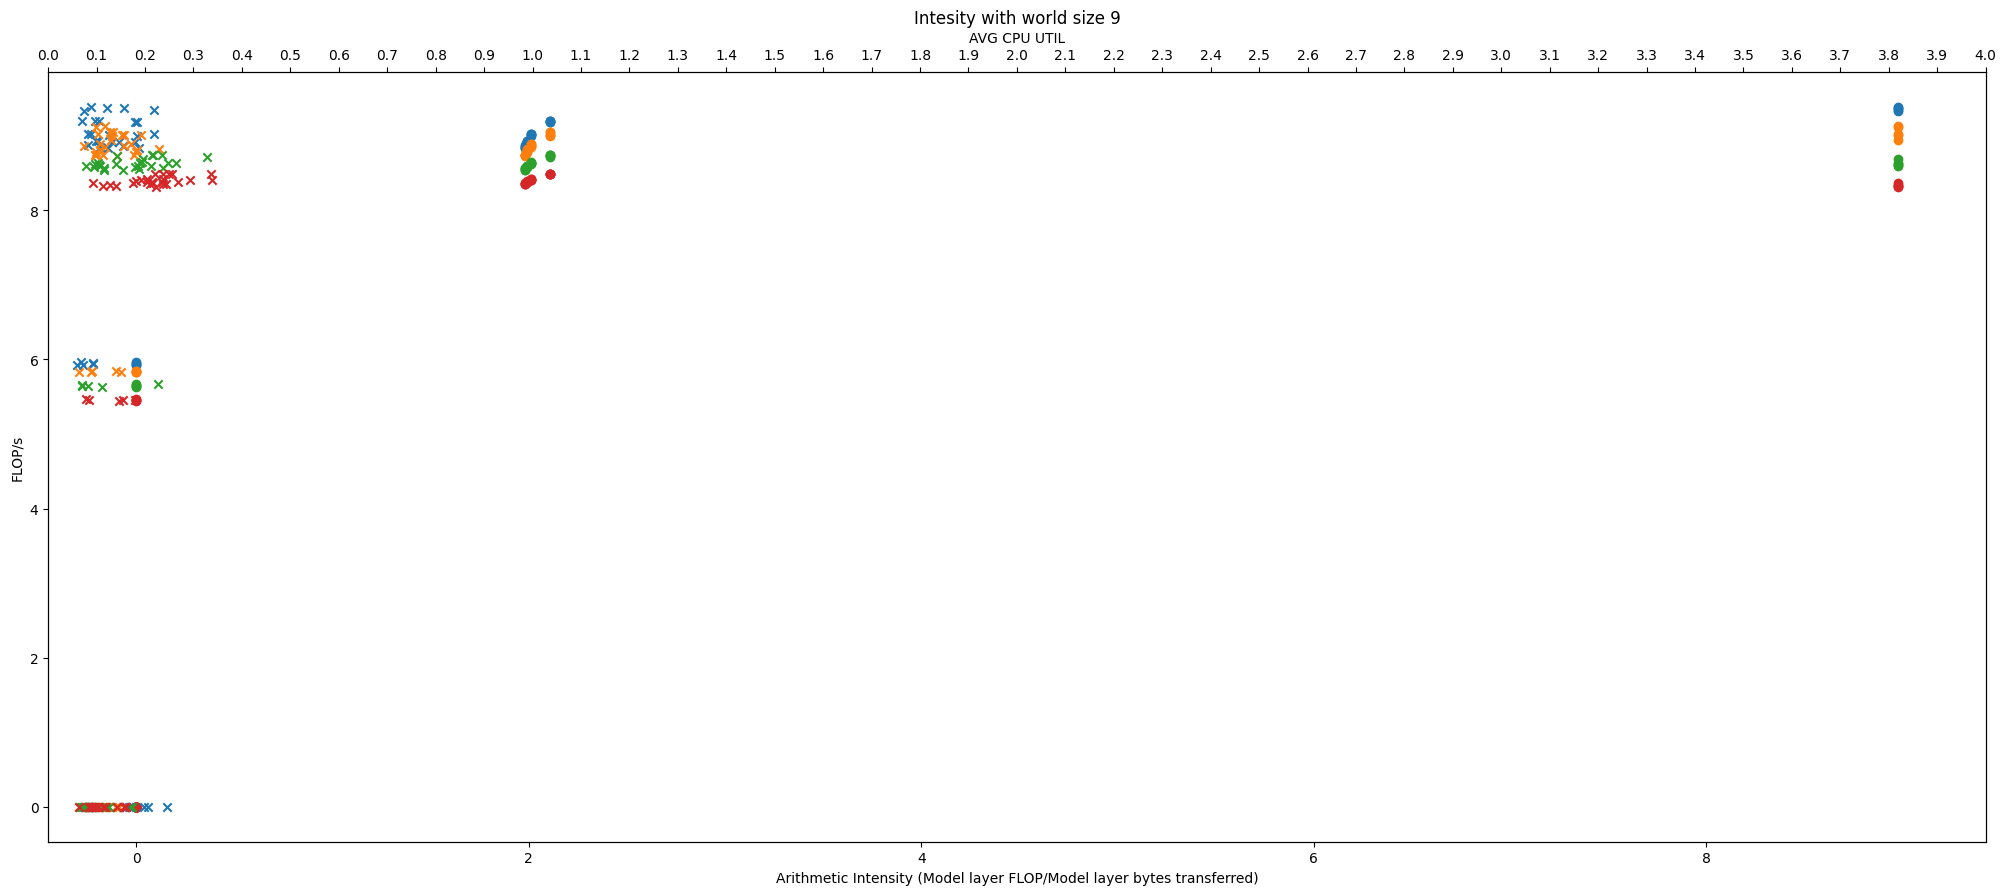

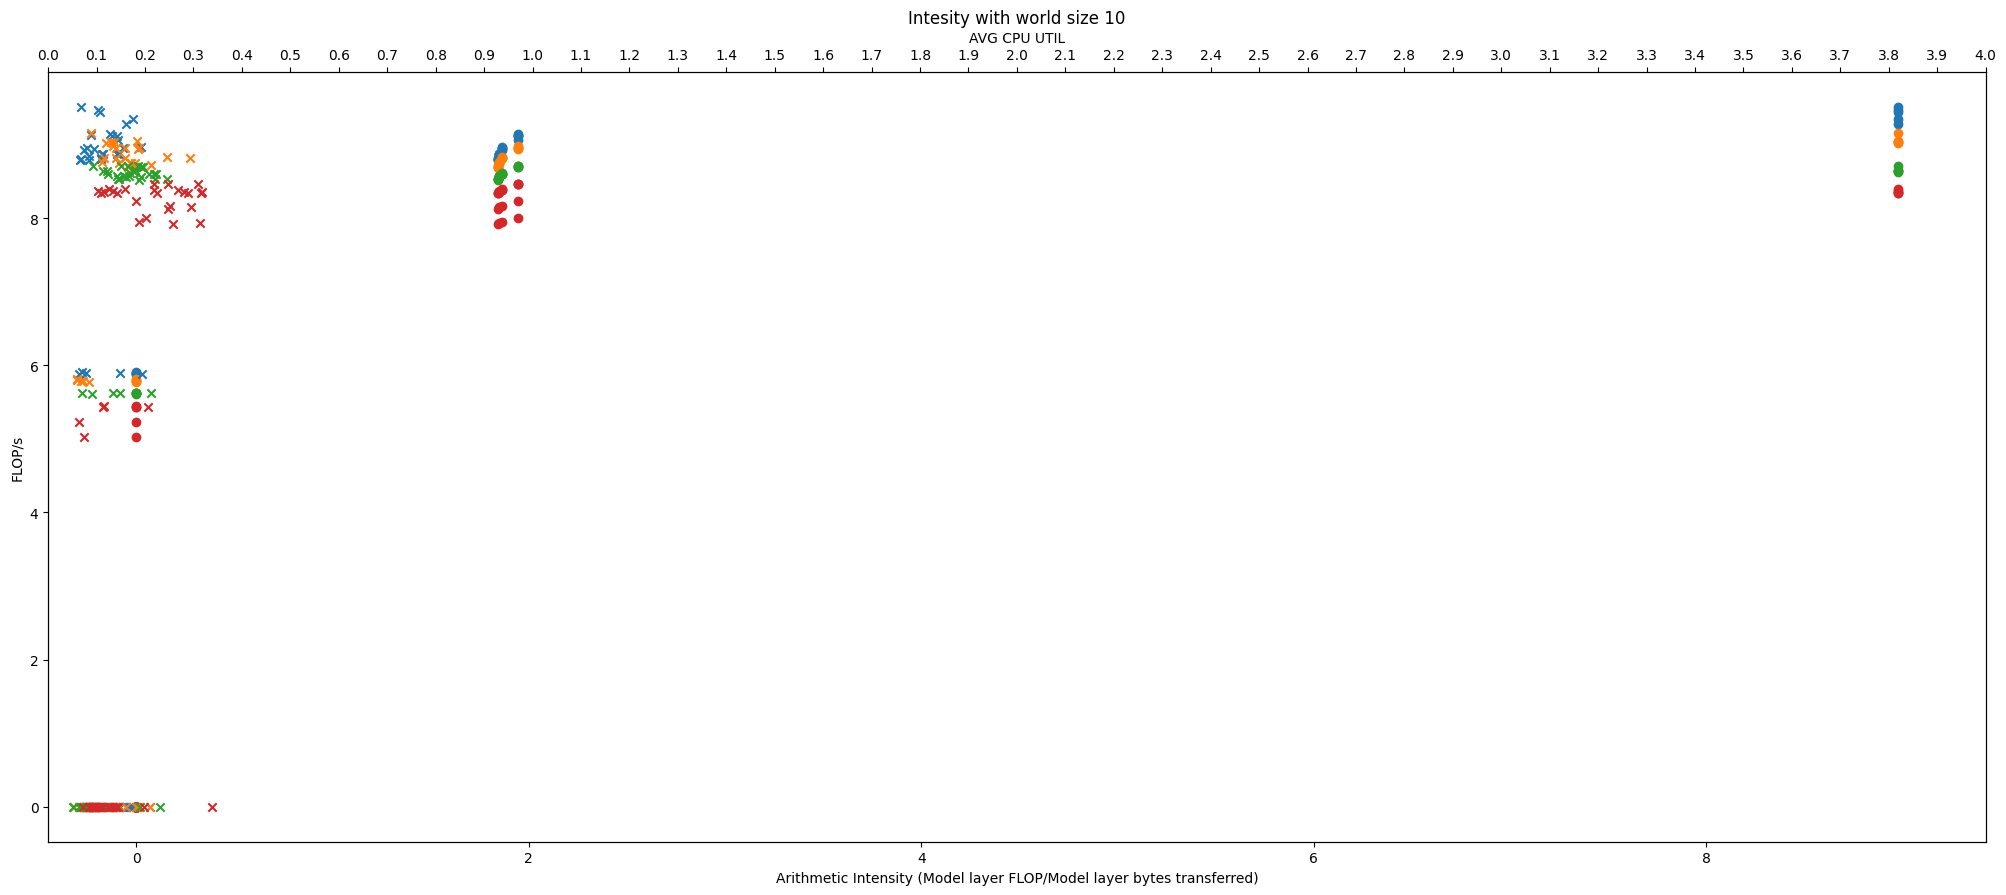

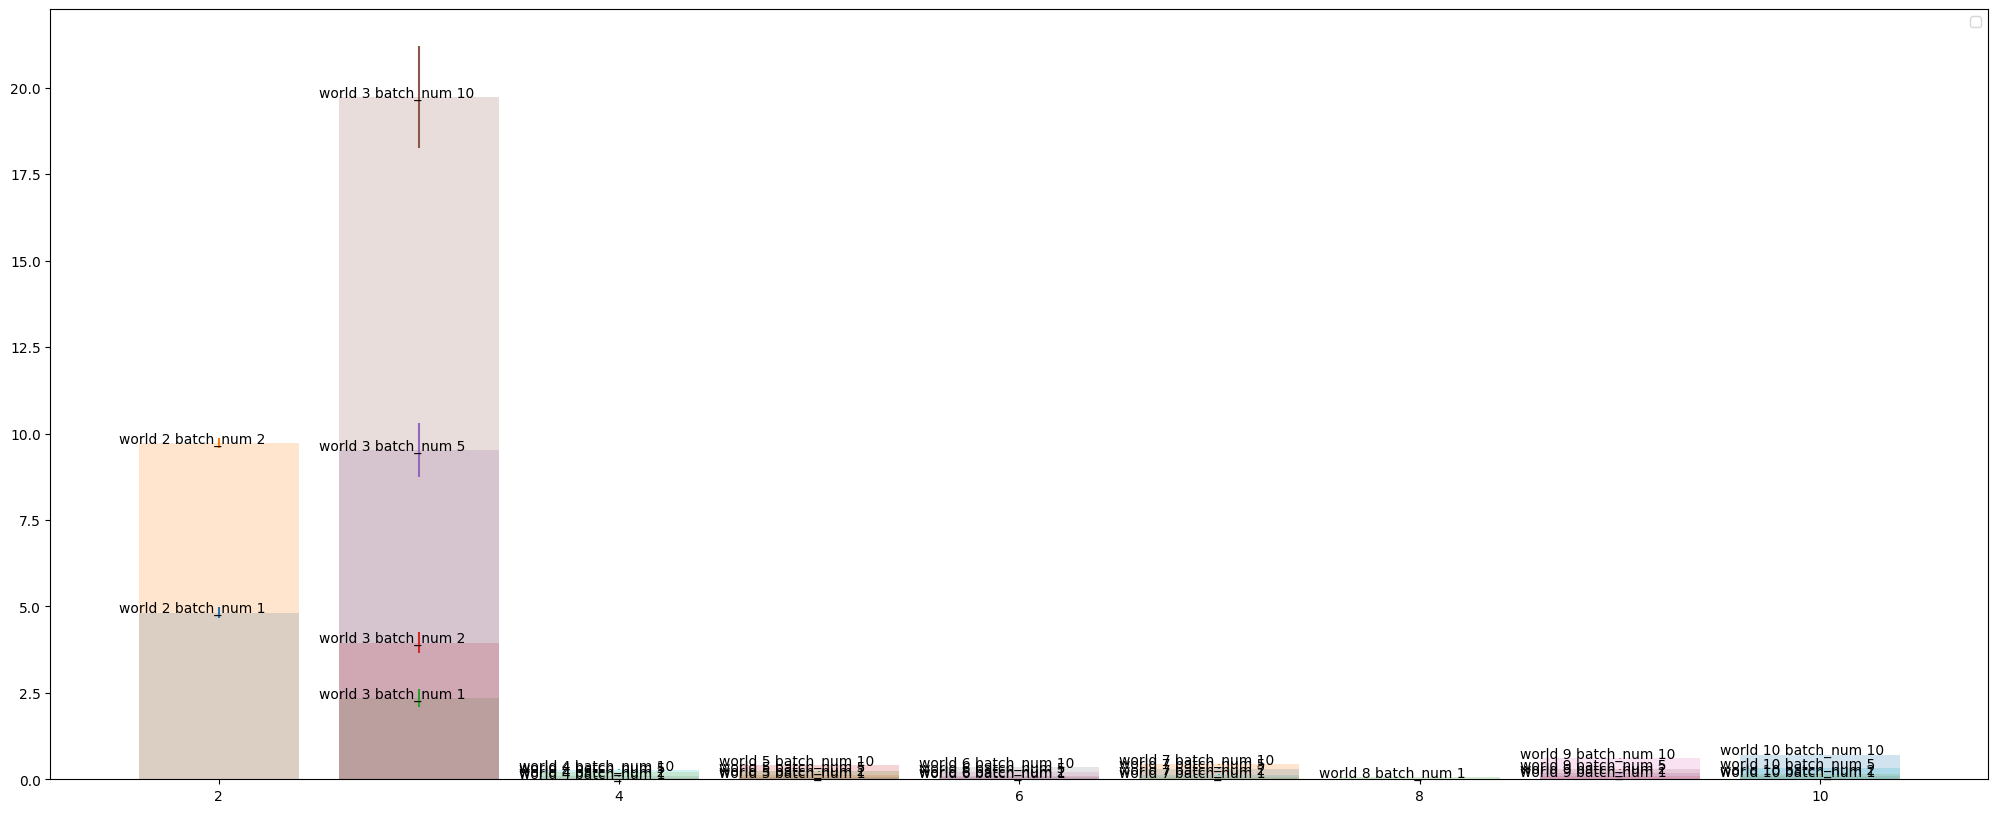

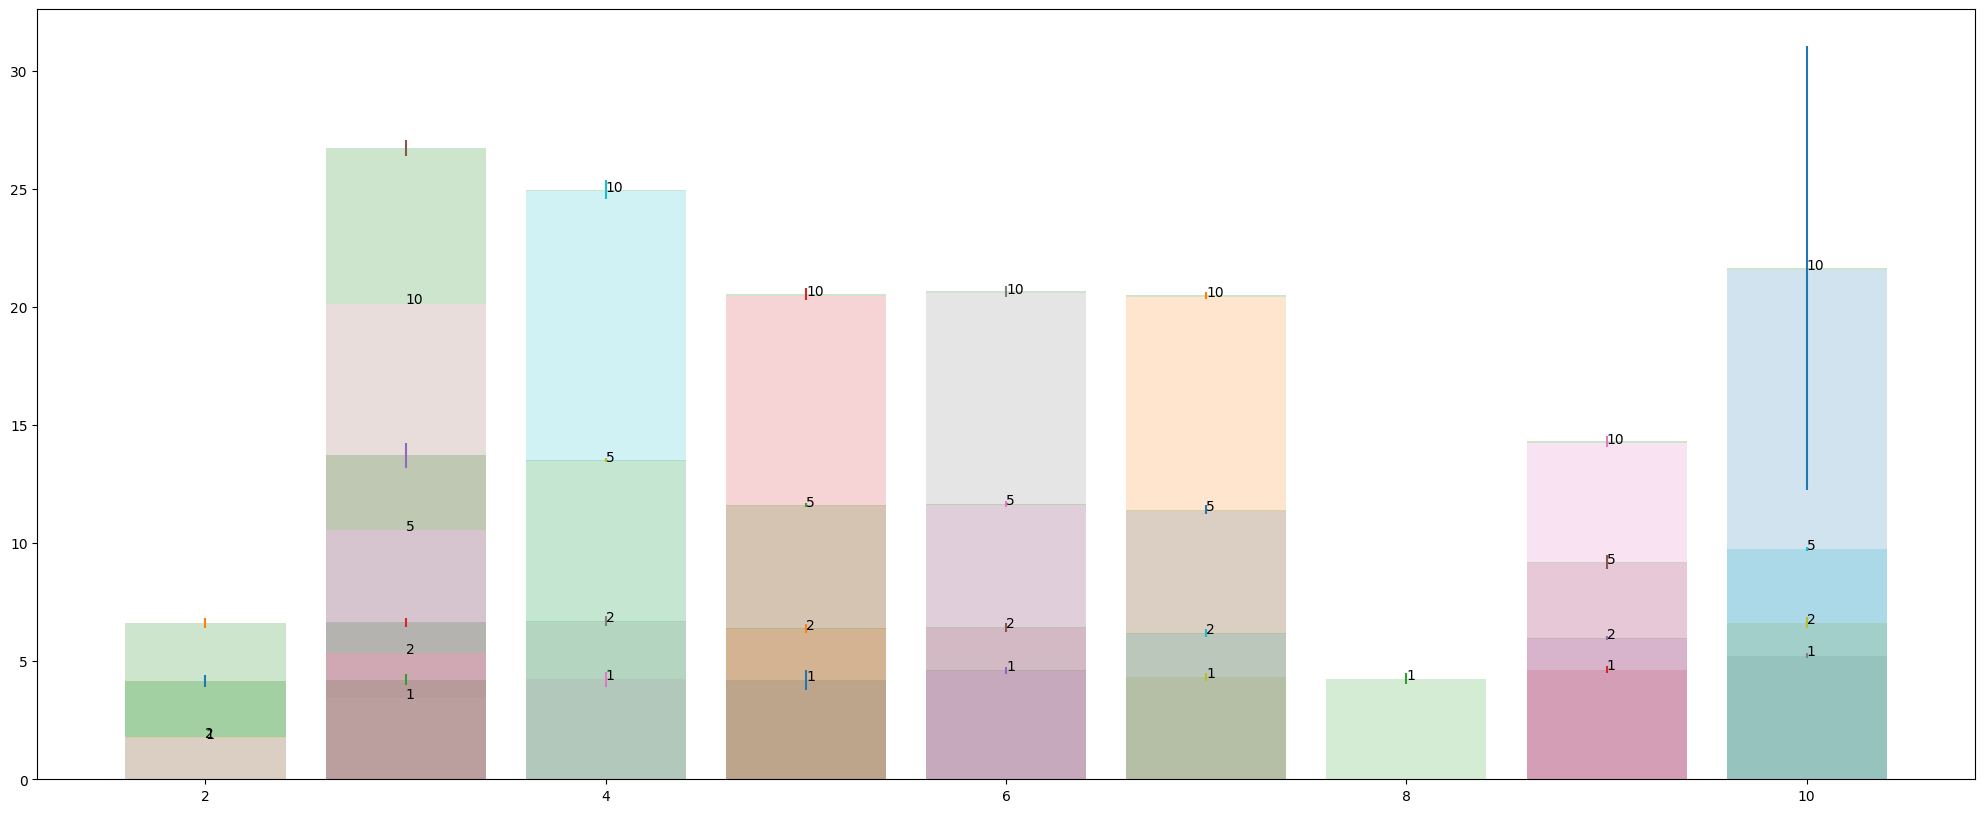

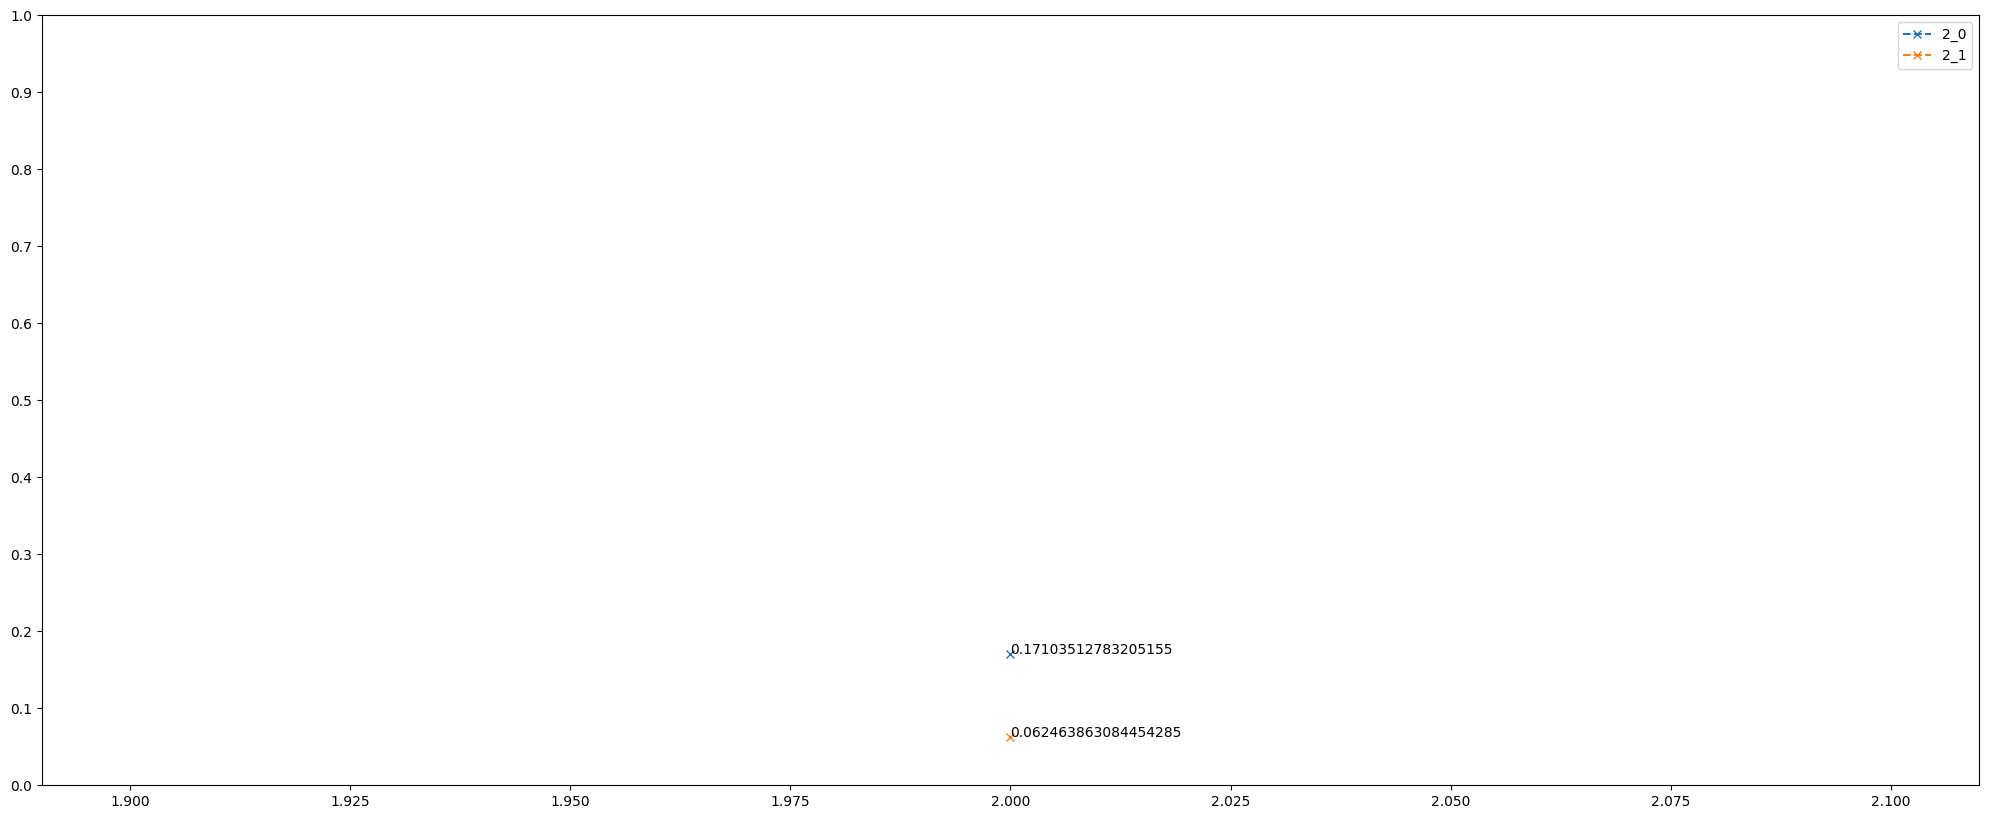

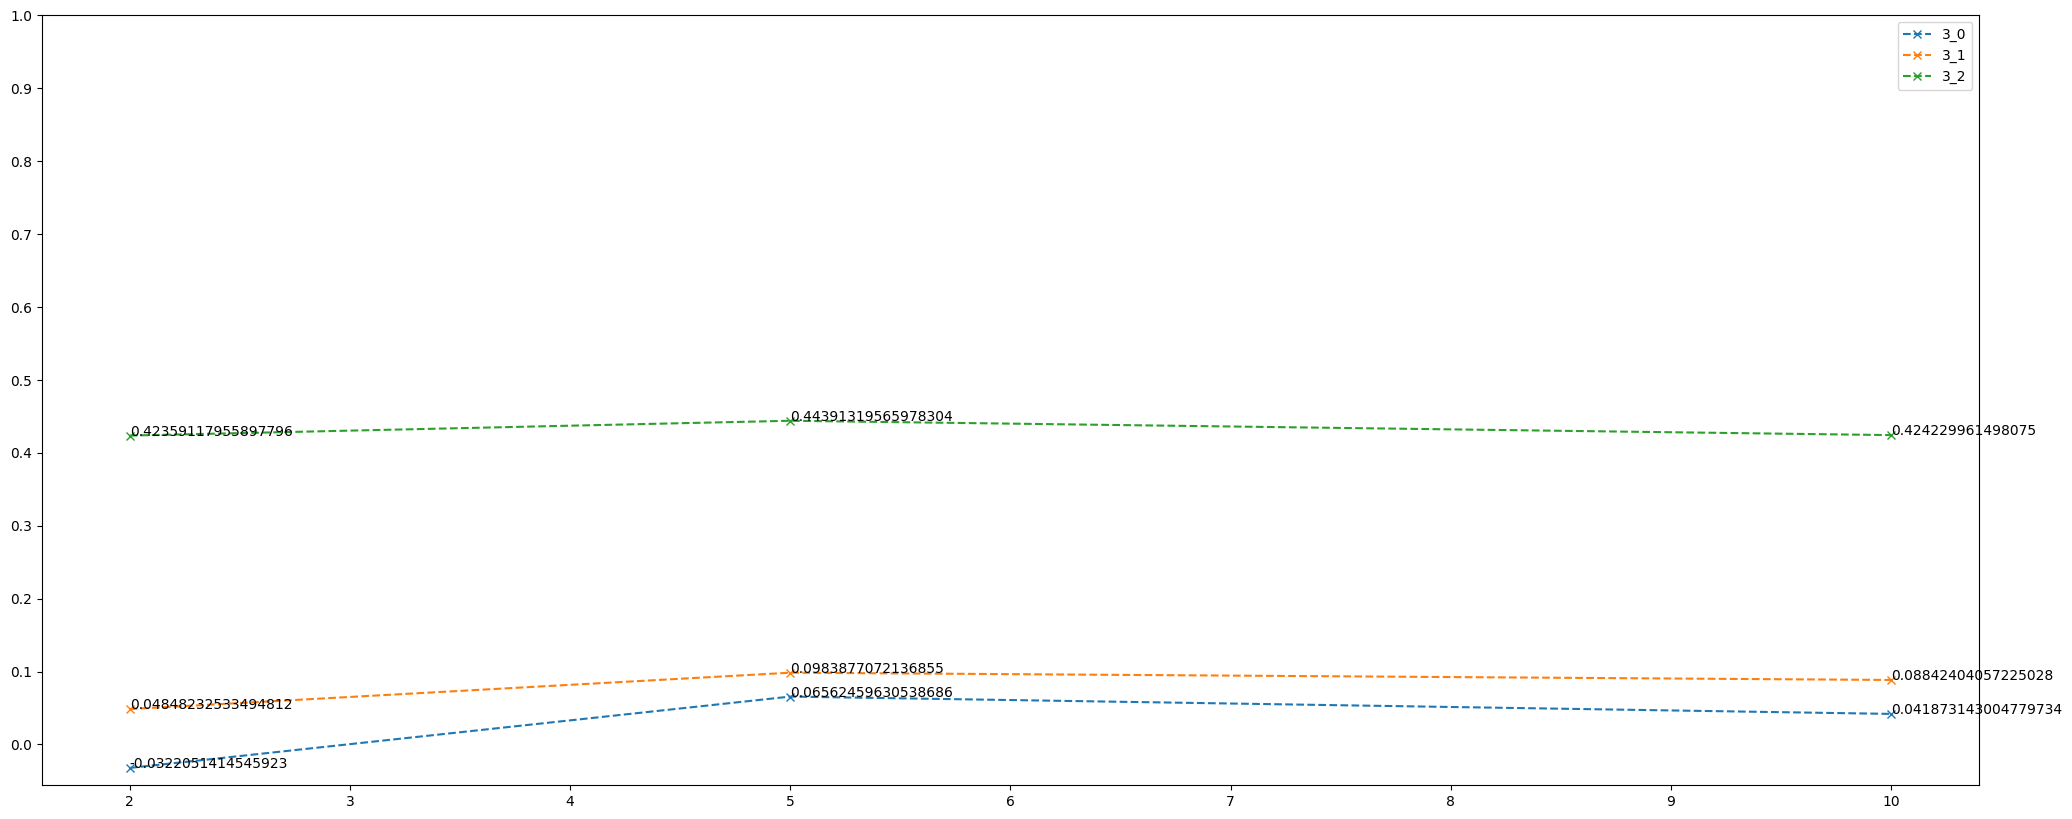

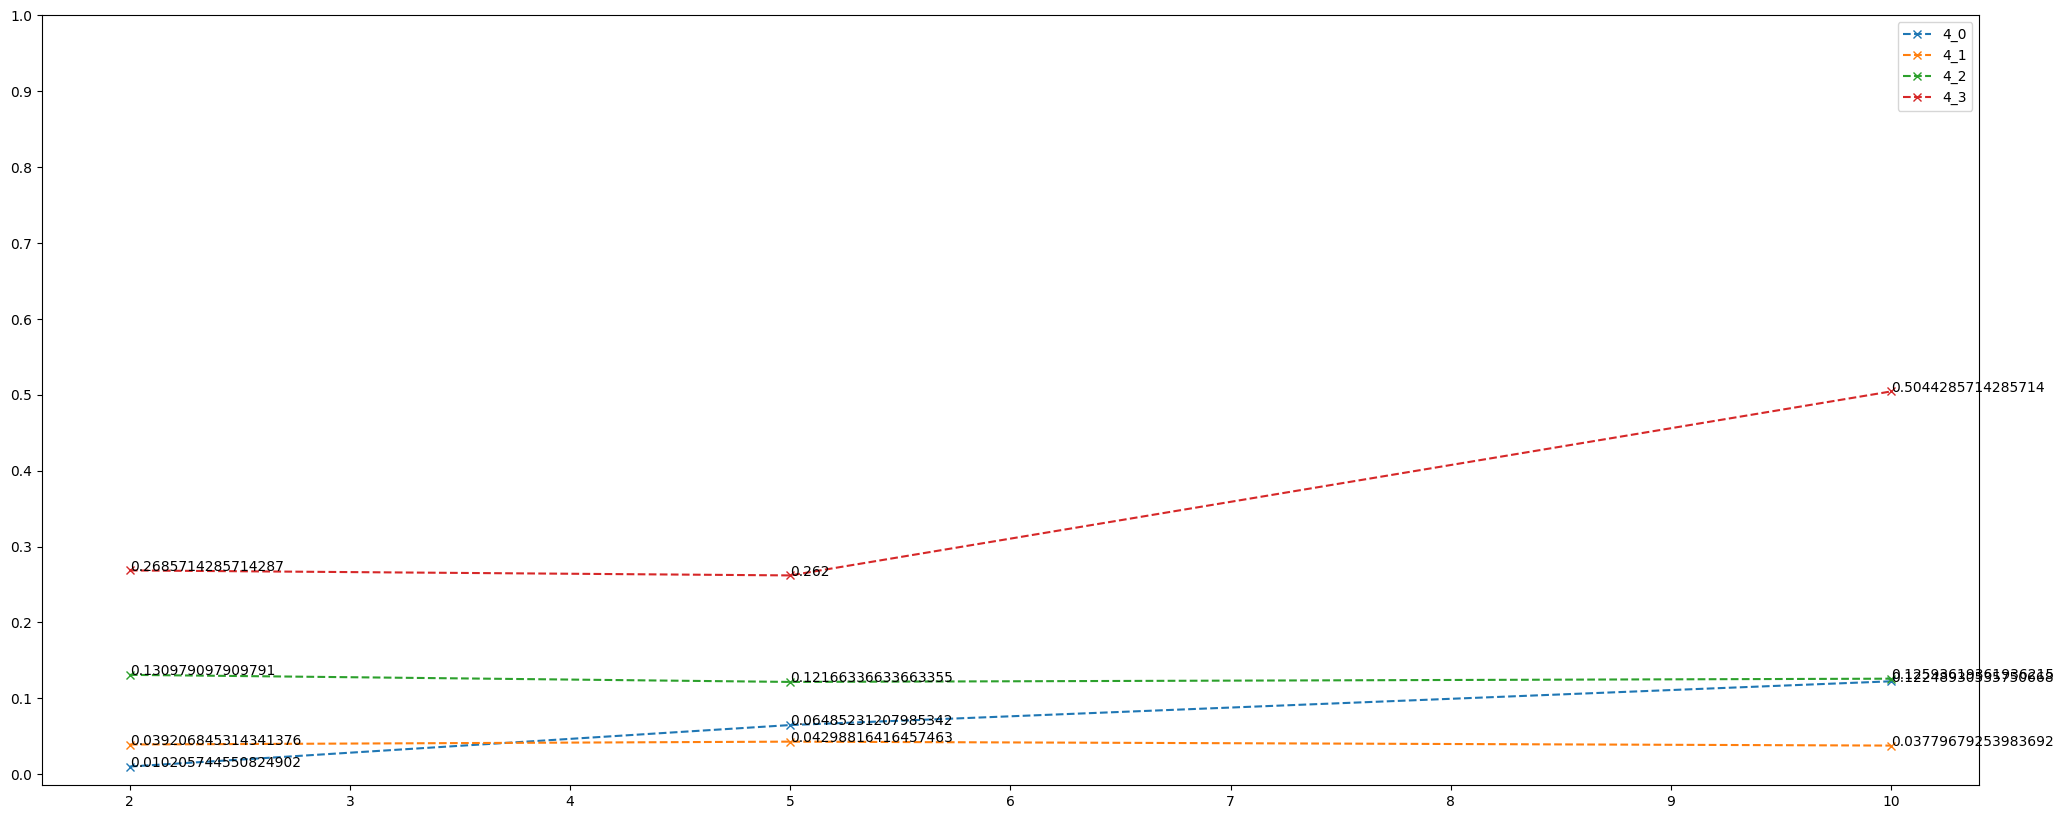

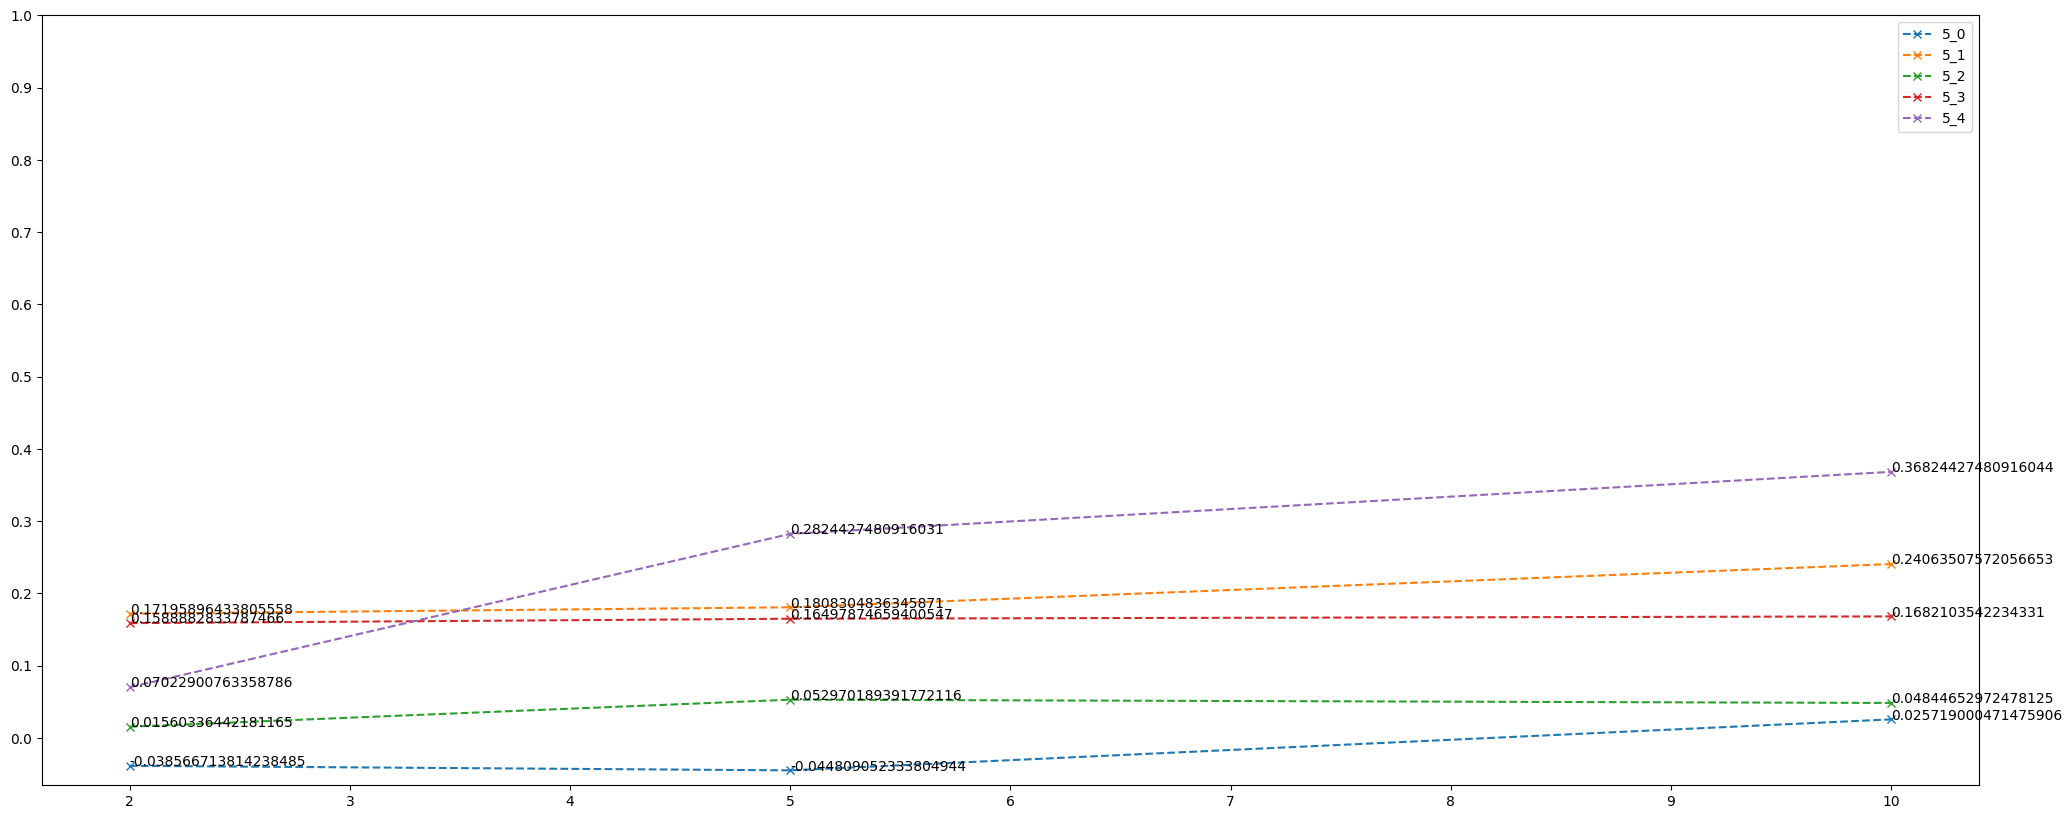

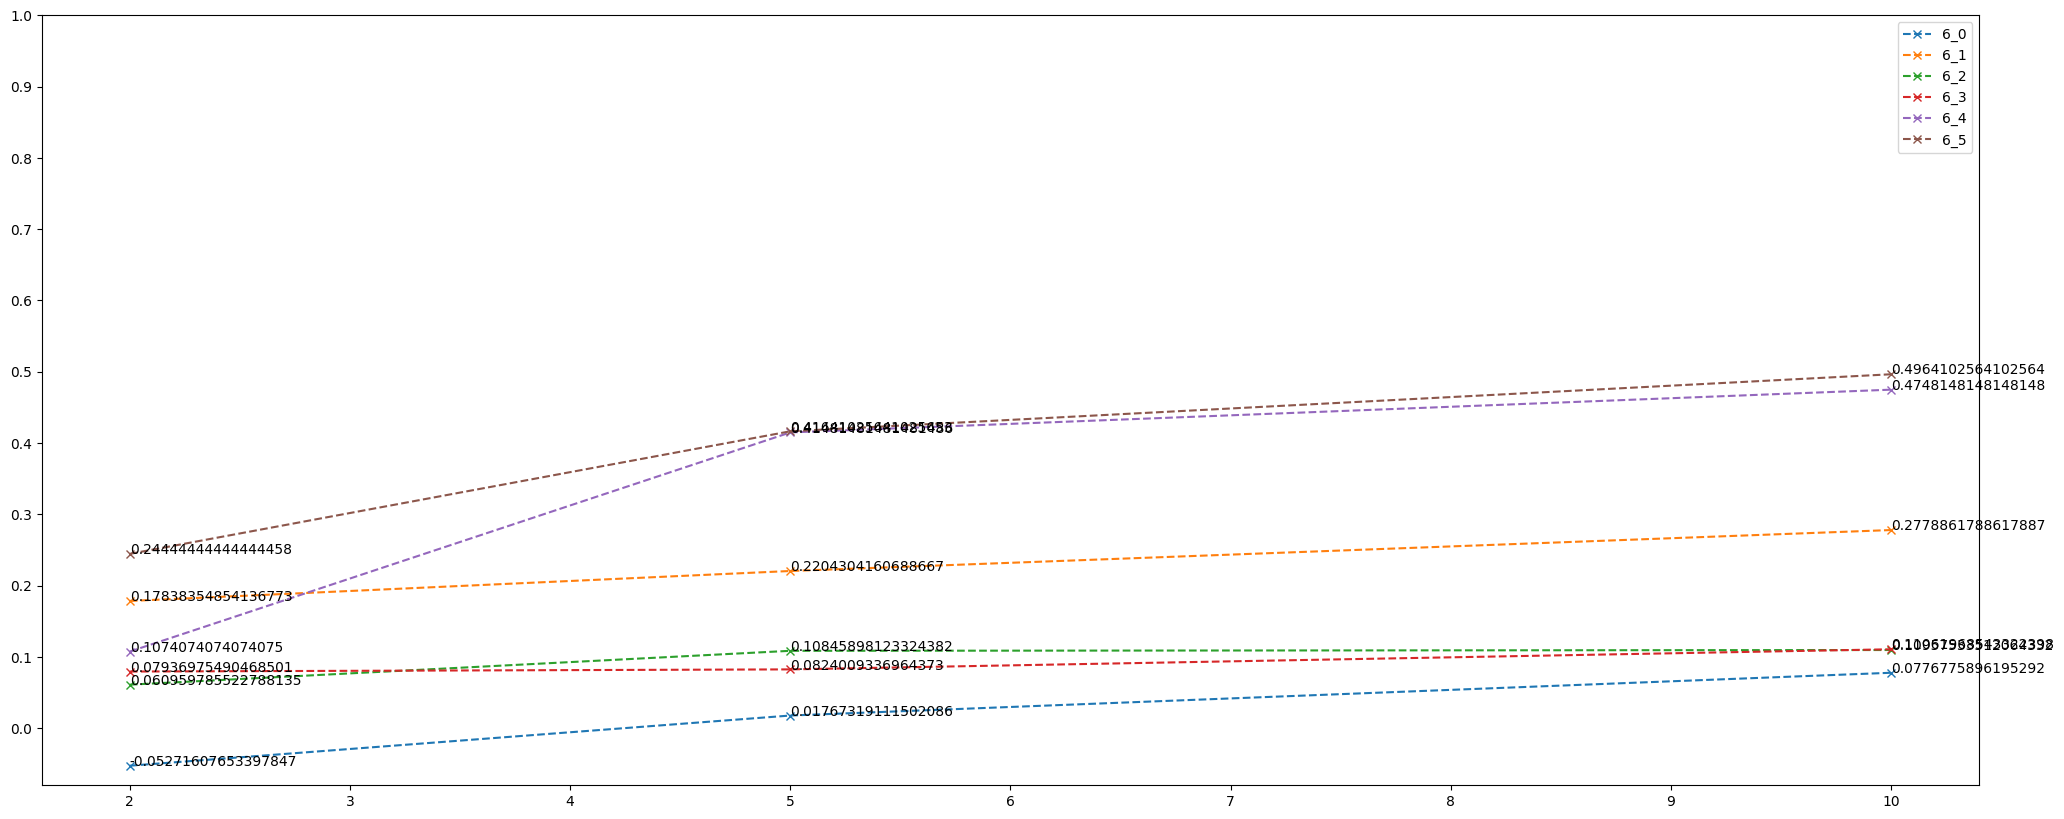

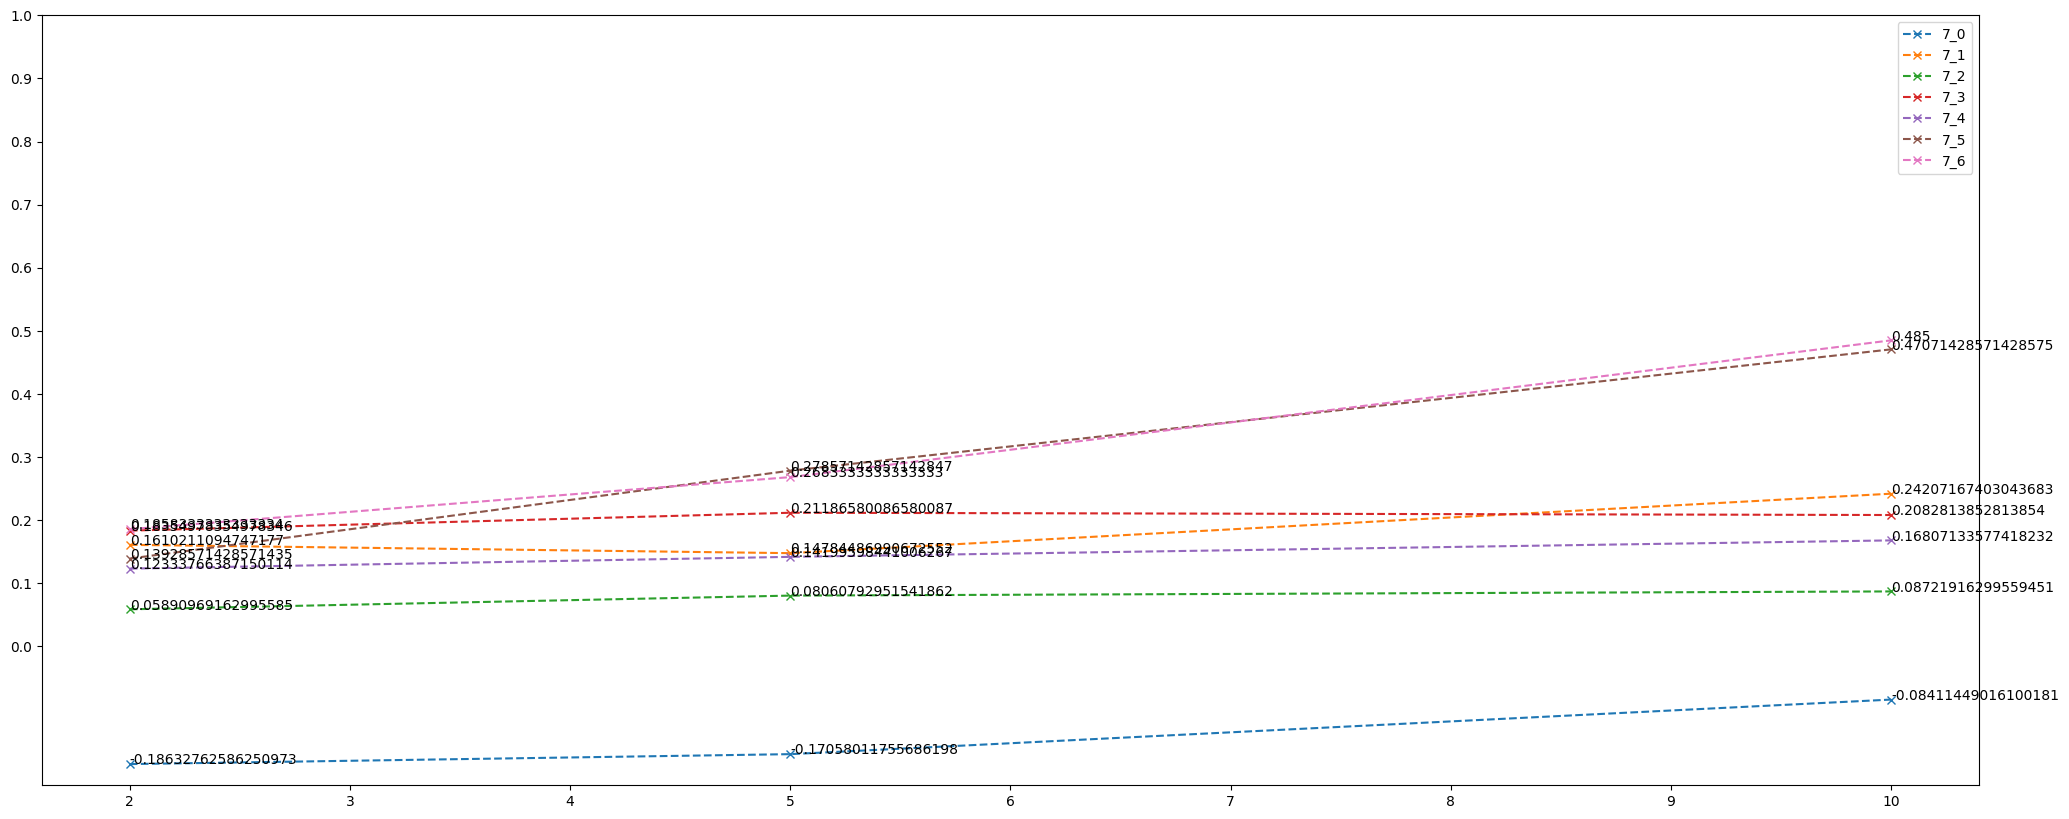

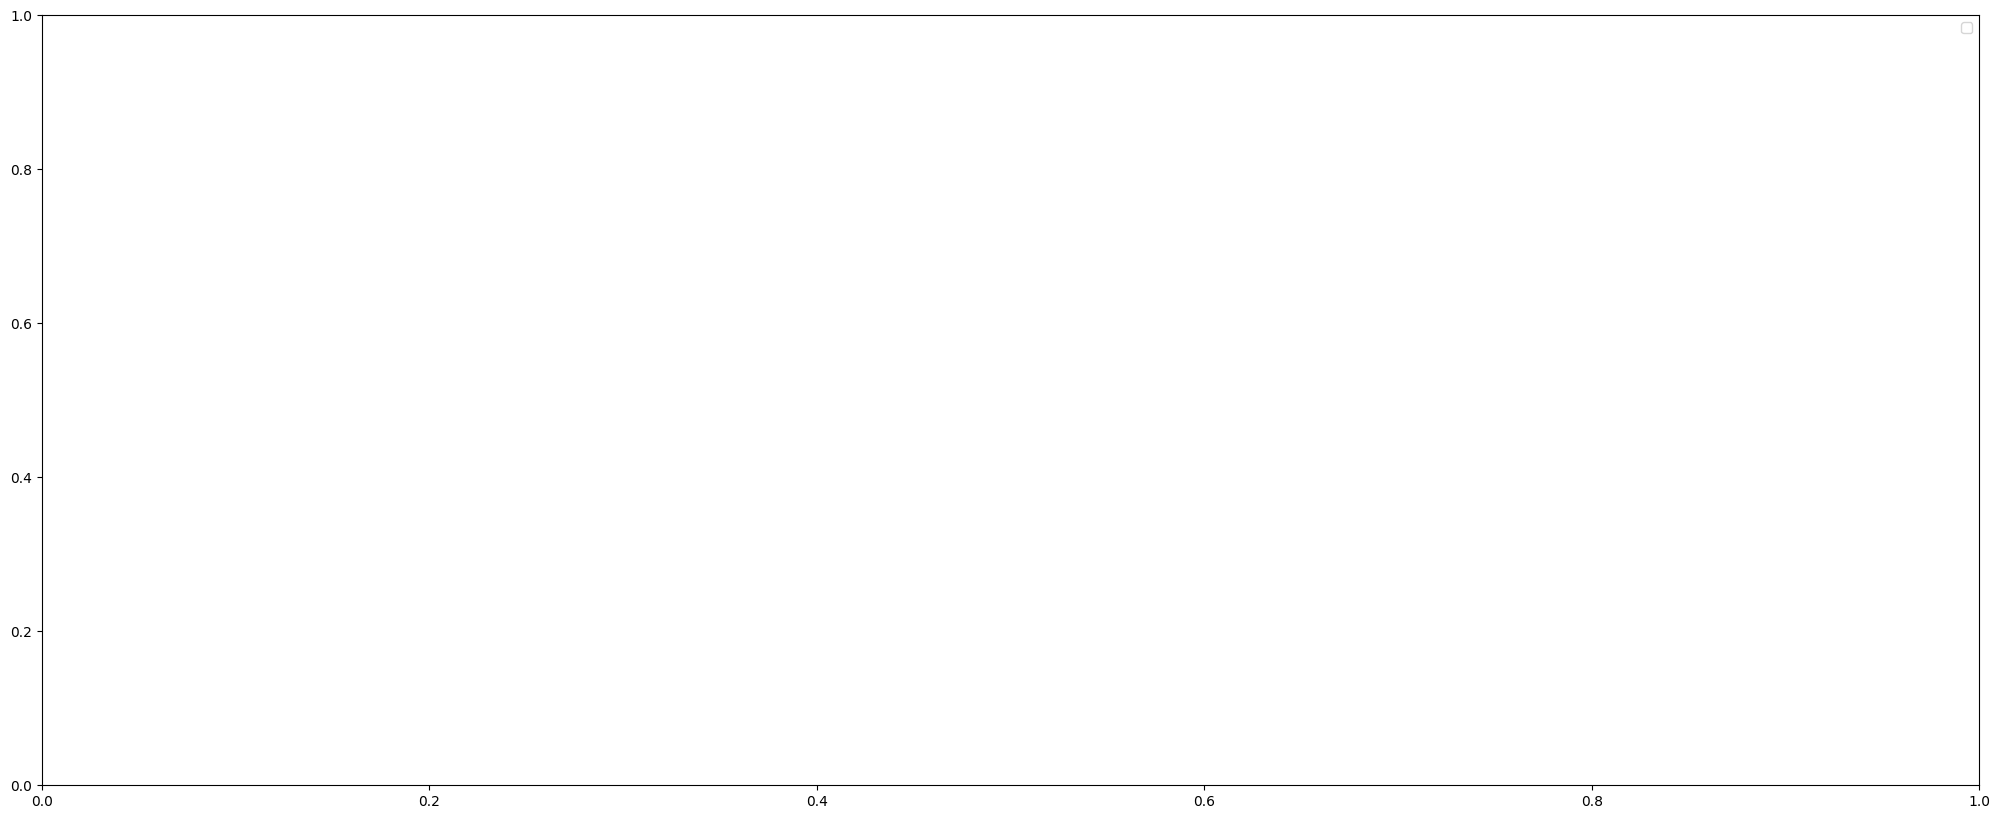

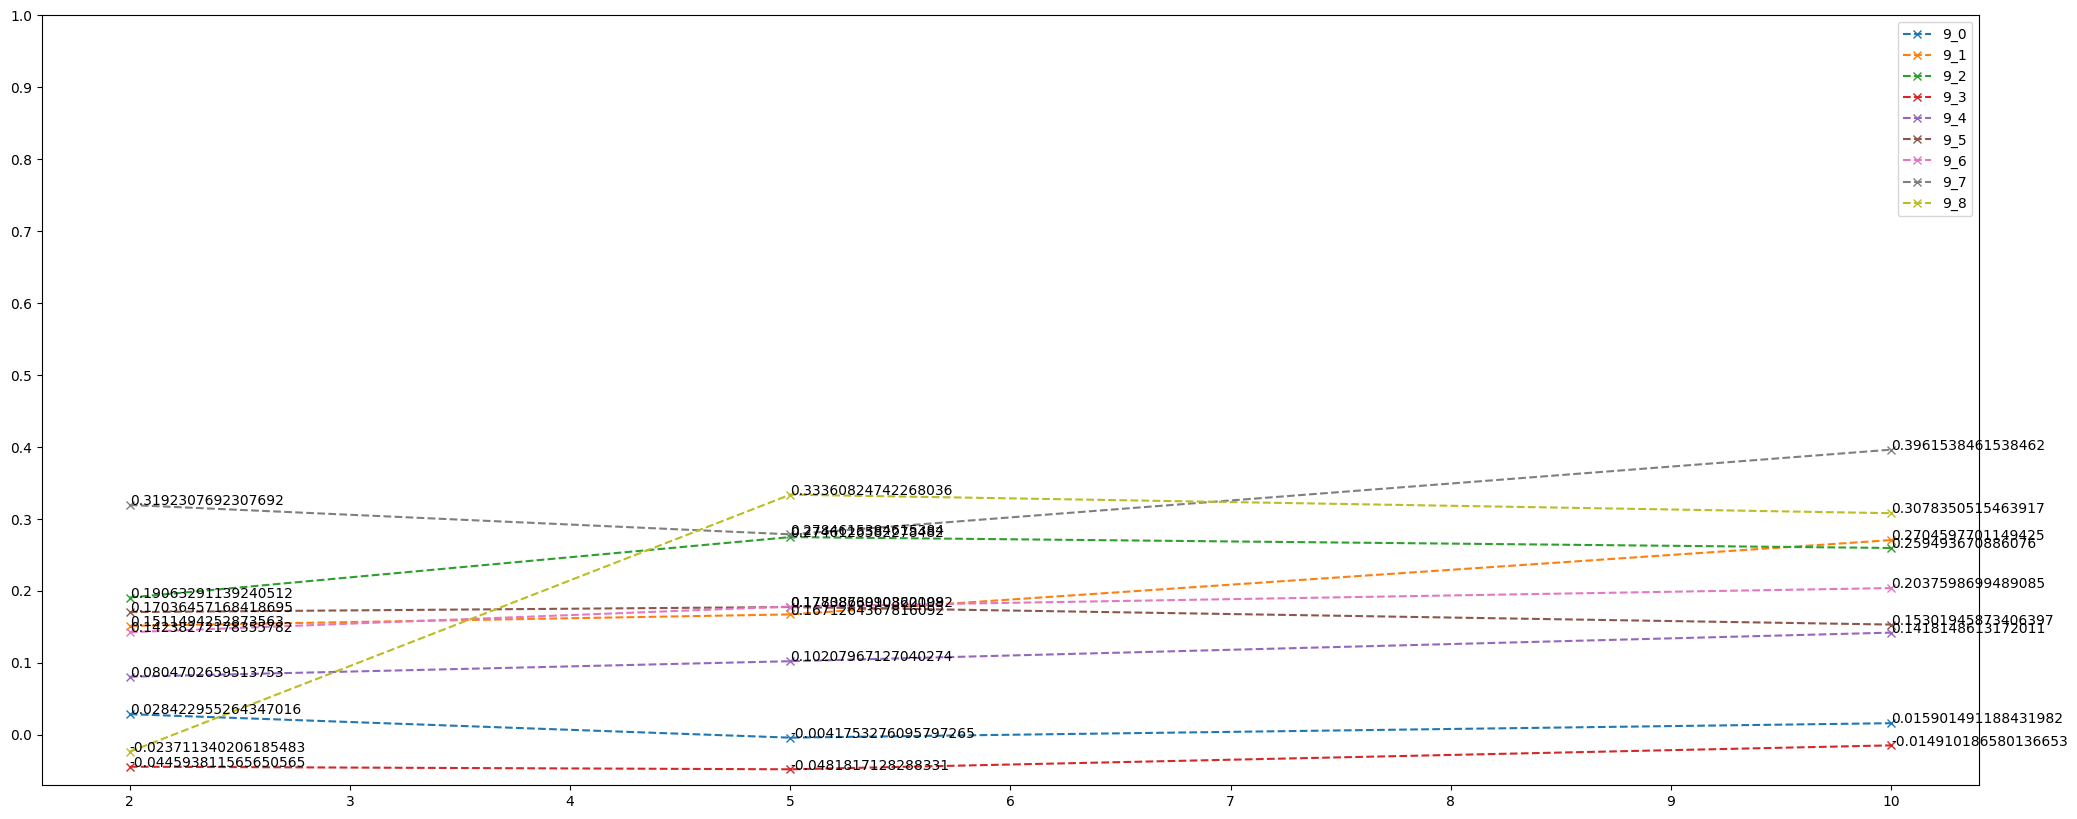

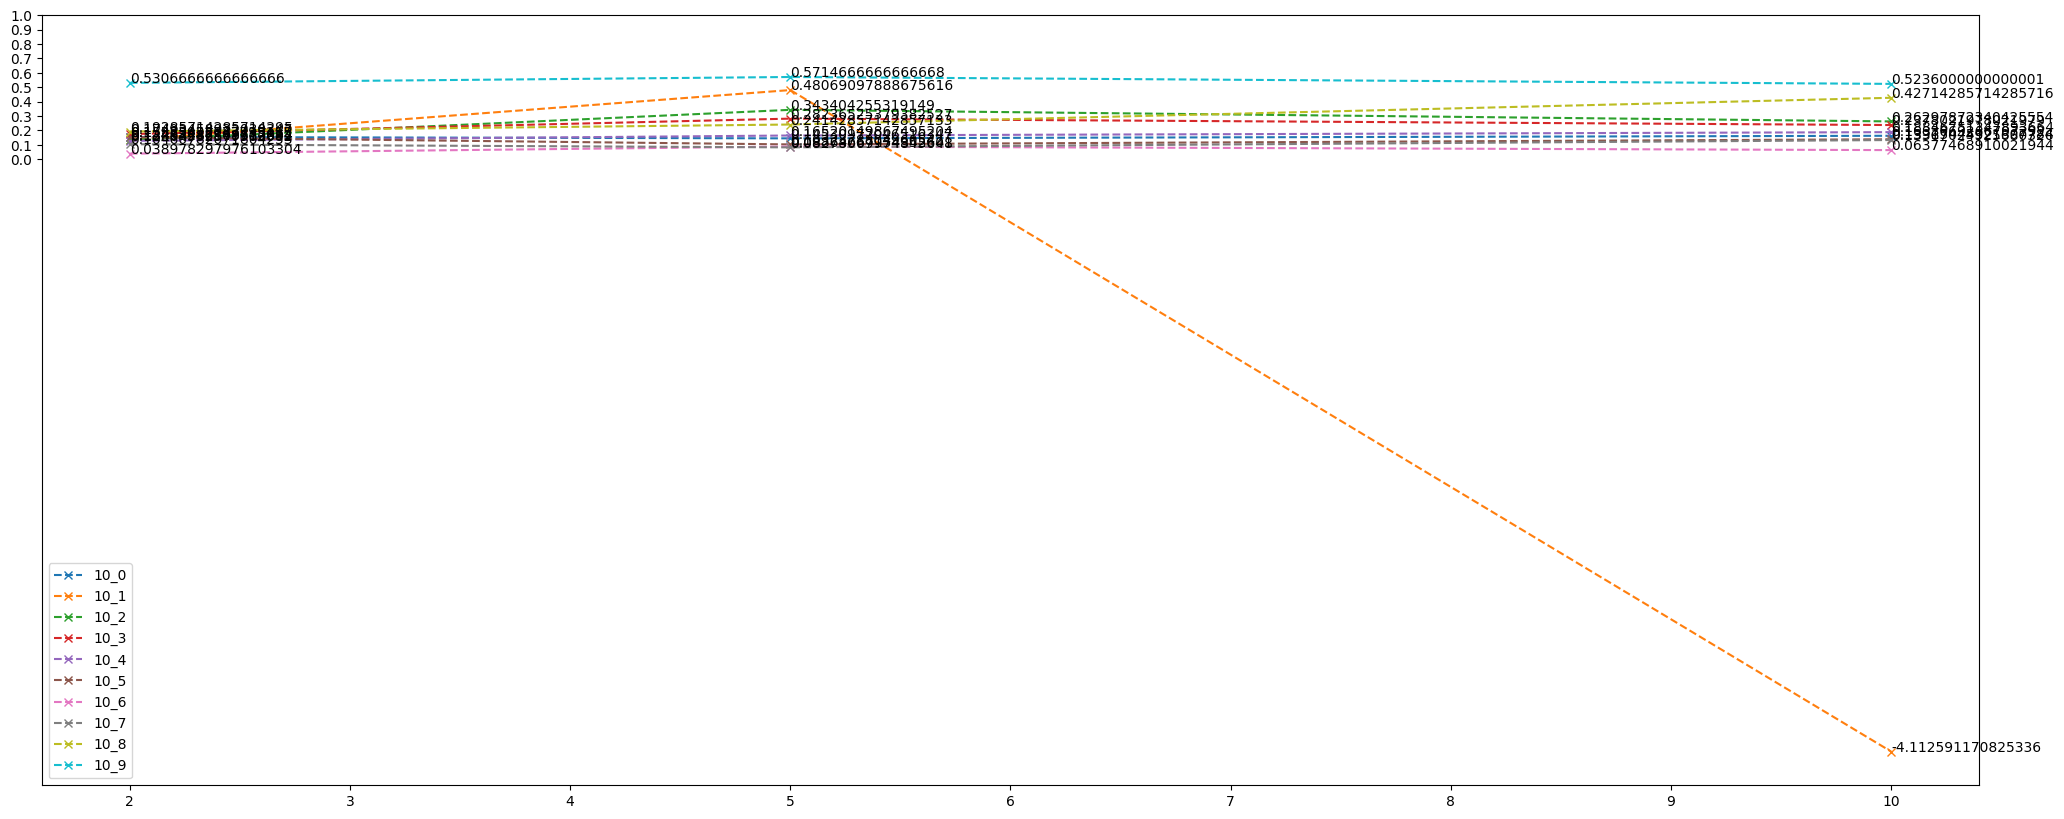

In [379]:
#on the pis

arith_intensity = {} #flops/bytes
flop_per_s = {} #flops/s
flops = {}
nets = {}
throttled_info = {}
tags = {}
cpu = {}
ctimes={}
ntimes={}
num_cores=4

#get max, min to normalize data across runs
g_flops = [0, np.inf]
g_bytes = [0, np.inf]
g_compute_t = [0, np.inf]

tl = [i for i in range(1,6)]
for repeat in tl:
    for i in [2,3,4,5,6,7,8,9,10]:
        if i not in arith_intensity:
            arith_intensity[i] = {}
            flop_per_s[i]={}
            flops[i]={}
            nets[i]={}
            ctimes[i]={}
            ntimes[i]={}
            throttled_info[i]={}
            tags[i]={}
            cpu[i]={}

        for batch_num in [1, 2, 5, 10]: #10 very rarely finished before timeout so checking why potentially because of tf?
            if batch_num not in arith_intensity[i]:
                arith_intensity[i][batch_num] = {}
                flop_per_s[i][batch_num]={}
                flops[i][batch_num]={}
                nets[i][batch_num]={}
                ctimes[i][batch_num]={}
                ntimes[i][batch_num]={}
                throttled_info[i][batch_num]={}
                tags[i][batch_num]={}
                cpu[i][batch_num]={}
            
            for batch in [2, 4]:
                if batch not in arith_intensity[i][batch_num]:
                    #hardcoded repeat len for now
                    arith_intensity[i][batch_num][batch] = [0]*i*len(tl) #repeat
                    flop_per_s[i][batch_num][batch]=[0]*i*len(tl) #repeat
                    flops[i][batch_num][batch]=[0]*i*len(tl) #repeat
                    nets[i][batch_num][batch]=[0]*i*len(tl) #repeat
                    ctimes[i][batch_num][batch]=[0]*i*len(tl) #repeat
                    ntimes[i][batch_num][batch]=[0]*i*len(tl) #repeat
                    throttled_info[i][batch_num][batch]=[0]*i*len(tl) #repeat
                    tags[i][batch_num][batch]=[0]*i*len(tl) #repeat
                    cpu[i][batch_num][batch]=[0]*i*len(tl) #repeat

            
                
                for rank in range(1,43):#range(0,i):
                    # pdu="bramble-4-5"
                    pdu="bramble-4-6"
                    c_fname = f"/Users/animeshnd/model_splitting/logs/roofline/resnet18_children_{pdu}/{repeat}/{i}_size/{batch}_{batch_num}/speed_chronos{pdu}-{rank}.log"
                    h_fname = f"/Users/animeshnd/model_splitting/logs/roofline/resnet18_children_{pdu}/{repeat}/{i}_size/{batch}_{batch_num}/speed_heat{pdu}-{rank}.log"
                    if Path(c_fname).is_file() and Path(h_fname).is_file():
                        # print(c_fname)
                        time_map, last_iter = time_reader(c_fname)
                        if time_map==None or len(time_map[1]["block_times"])==0 or len(time_map[1]["net_times"])==0:
                            continue
                        l_rank = time_map[1]["rank"]
                        l_rank += i*(repeat-1)
                        flop = time_map[1]["flop"]
                        # comp_t = time_map[1]["comp_t"] #- time_map[1]["nw"]
                        # comp_t = time_map[1]["comp_t"] - time_map[1]["nw_t"]
                        # print(np.mean(time_map[1]["net_times"]), time_map[1]["nw_t"], time_map[1]["nw"] )
                        # comp_t = time_map[1]["comp_t"]#sum(set(time_map[1]["block_times"]))#*batch_num #time_map[1]["comp_t"] - np.mean(time_map[1]["net_times"])*batch_num
                        comp_t = time_map[1]["comp_t"] if time_map[1]["rank"]!=0 else sum(set(time_map[1]["block_times"]))#*batch_num #time_map[1]["comp_t"] - np.mean(time_map[1]["net_times"])*batch_num
                        # ctimes[i][batch_num][batch].append(time_map[1]["comp_t"])
                        ctimes[i][batch_num][batch][l_rank] = sum(set(time_map[1]["block_times"]))#time_map[1]["comp_t"] #include network time
                        ntimes[i][batch_num][batch][l_rank] = sum(set(time_map[1]["net_times"]))
                        # print(comp_t, time_map[1]["comp_t"] - sum(set(time_map[1]["net_times"])))
                        # print(comp_t)
                        # g_compute_t[0] = g_compute_t[0] if g_compute_t[0] >= comp_t else comp_t
                        # g_compute_t[1] = g_compute_t[1] if g_compute_t[1] <= comp_t else comp_t

                        block_times = time_map[1]["block_times"]
                        sent_b = time_map[1]["sent"]
                        recv_b = time_map[1]["recv"]

                        # if l_rank==6 and i==7:
                        #     print(comp_t) 
                        
                        # flop = np.log10(flop if flop>0 else 1)
                        # print(time_map[1]["block_times"])
                        flop_per_s[i][batch_num][batch][l_rank] = flop/comp_t
                        # flop_per_s[i][batch_num][batch].append(flop/np.mean(block_times))
                        flops[i][batch_num][batch][l_rank] = flop
                        # g_flops[0] = g_flops[0] if g_flops[0] >= flop else flop
                        # g_flops[1] = g_flops[1] if g_flops[1] <= flop else flop

                        nets[i][batch_num][batch][l_rank] = sent_b#+recv_b
                        # g_bytes[0] = g_bytes[0] if g_bytes[0]>= sent_b+recv_b else sent_b+recv_b
                        # g_bytes[1] = g_bytes[1] if g_bytes[1]<= sent_b+recv_b else sent_b+recv_b

                        # arith_intensity[i][batch_num][batch][l_rank] = flop/(sent_b+recv_b)
                        l_rank_no_offset = time_map[1]["rank"]
                        tags[i][batch_num][batch][l_rank] = f"{l_rank_no_offset}_{i}"

                        heat_map = heat_reader(h_fname, last_iter)
                        # print(heat_map)
                        temp_cpu = [t['cpu'] for t in heat_map.values()]
                        temp_thr = [ (1 if t["throttled"]==False else 0) for t in heat_map.values() ]#[:int(np.ceil(comp_t))] 
                        # temp_thr = temp_thr if len(temp_thr) > 1 else [0] #if comp_t > 1 else [0]
                        
                        #with very precise slices using timings window

                        # temp_thr = [ (1 if t["throttled"]==False else 0) for t in heat_map.values() ]
                        # accum=0
                        # for s_ind, s in enumerate(time_map[1]["timing"]):
                        #     st = int(np.floor(s))
                        #     if s_ind==0 :
                        #         continue
                        #     if s_ind == len(time_map[1]["block_times"]):
                        #         break
                        #     # print(time_map[1]["block_times"], s_ind, time_map[1]["timing"])
                        #     et = int(np.floor(s+time_map[1]["block_times"][s_ind]))
                        #     print(st, et, time_map[1]["block_times"][s_ind])
                        #     accum += sum(temp_thr[st:et])
                        # accum = accum/sum(set(time_map[1]["block_times"]))
                        # print(accum, sum(set(time_map[1]["block_times"])))


                        # print(temp_cpu)
                        cpu[i][batch_num][batch][l_rank] = ( (np.mean(temp_cpu)/num_cores))
                        # throttled_info[i][batch_num][batch][l_rank] = ( sum(temp_thr)/len(temp_thr) ) #within a layerx
                        # throttled_info[i][batch_num][batch][l_rank] = sum(temp_thr)  #whole model
                        throttled_info[i][batch_num][batch][l_rank] = [te for te in temp_thr]  #everything lmaos
                        # throttled_info[i][batch_num][batch][l_rank] =  accum #within a layer
                        # print(len(temp_thr), time_map[1]["comp_t"], i, l_rank_no_offset, sum(set(time_map[1]["block_times"])) + sum(set(time_map[1]["net_times"])))
                        # throttled_info[i][batch_num][batch][l_rank] = ( sum(temp_thr) ) #within the entire compute
                        # cpu.append( np.max(temp_cpu)/num_cores)
                        # print(heat_map)
                        # break
                    # break
                # break
            # break

#for bramble-4-5 it's 31, bramble-4-6 it;s 36? 
# worst_4_pred = [ [tf_calc(i, 31)*j for j in range(1,5)] for i in range(1,5)]
worst_4_pred = [ [tf_calc(j, 31 if pdu=="bramble-4-5" else 36) for j in range(1,30)]]

print(worst_4_pred)#, np.sum([worst_4_pred[i][0] for i in range(0,3)]))
# TODO NORMALISE THE FLOPS AND BYTES TRANSFERRED PLEASE 
# print(arith_intensity)
counter={}
repeat_counter={}
# for i in arith_intensity:
for i in flop_per_s:
    fig, axs = plt.subplots(figsize=(25,10))
    # fig, taxs = plt.subplots(figsize=(25,10))
    ax1 = axs.twiny()
    # if i not in counter:
    #     counter[i]=0
    # counter[i]=0 

    # for batch_num in arith_intensity[i]:
    for batch_num in flop_per_s[i]:
        # for batch in arith_intensity[i][batch_num]:
        for batch in flop_per_s[i][batch_num]:
            if batch!=4:  
                continue
            if len(nets[i][batch_num][batch])==0 or len(flops[i][batch_num][batch])==0:
                continue
            min_nets = min(nets[i][batch_num][batch])
            max_nets = max(nets[i][batch_num][batch])
            min_flop = min(flops[i][batch_num][batch])
            max_flop = max(flops[i][batch_num][batch])
            if min_flop==max_flop or max_nets==min_nets:
                continue
            # print(net)
            # print(flops[i][batch_num][batch])
            # print(nets[i][batch_num][batch])
            # print(arith_intensity, flop_per_s)
            #normalize across ranks
            # n_flops = [ (k-min_flop)/(max_flop-min_flop) for k in flops[i][batch_num][batch]]
            # n_flops = [ k for k in flops[i][batch_num][batch]]
            
            # # n_nets = [(k-min_nets)/(max_nets-min_nets) for k in nets[i][batch_num][batch]]
            # n_nets = [k for k in nets[i][batch_num][batch]]
            # n_arith_intensity = [ np.log10(n_flops[k_ind]/n_nets[k_ind]) if n_flops[k_ind]>0 and n_nets[k_ind]>0 else 0 for k_ind in range(len(n_flops))]


            # t_arith_intensity = [ k for k in arith_intensity[i][batch_num][batch] if k >= 0]
            t_tags = [ k for k_ind, k in enumerate(tags[i][batch_num][batch]) if flop_per_s[i][batch_num][batch][k_ind] >= 0]
            if 0 in t_tags:
                # print(t_tags, i)
                continue
            # t_arith_intensity = [ np.log10(k if k != 0 else 1) for k in arith_intensity[i][batch_num][batch] if k >= 0]
            
            nt = [sum(nets[i][batch_num][batch][:int(k.split("_")[0])]) for k in t_tags]
            nt = [ (k if k!=0 else 1) for k in nt]

            t_arith_intensity = [ np.log10(k/nt[k_ind] if k != 0 and k >= nt[k_ind] else 1) for k_ind, k in enumerate(flops[i][batch_num][batch]) if k >= 0]
            # t_arith_intensity = [ (k*10**-6/nt[k_ind] if nt[k_ind]==1 else k/nt[k_ind]) for k_ind, k in enumerate(flops[i][batch_num][batch]) if k >= 0]
            # t_arith_intensity = [ k for k in arith_intensity[i][batch_num][batch] if k >= 0]
            # if len(t_arith_intensity) == 0:
            #     continue
            t_flop_per_s = [ np.log10(k if k != 0 else 1 ) for k in flop_per_s[i][batch_num][batch] if k >= 0]
            # t_flop_per_s = [ k for k in flop_per_s[i][batch_num][batch] if k >= 0]
            # t_flop_per_s = [ k for k in flop_per_s[i][batch_num][batch] if k >= 0]
            t_cpu = [ k for k_ind, k in enumerate(cpu[i][batch_num][batch]) if flop_per_s[i][batch_num][batch][k_ind] >= 0]
            t_times = [k for k_ind, k in enumerate(ctimes[i][batch_num][batch]) if flop_per_s[i][batch_num][batch][k_ind] >=0 ]
            t_throttled_info = [ k for k_ind, k in enumerate(throttled_info[i][batch_num][batch]) if flop_per_s[i][batch_num][batch][k_ind] >= 0]
            t_flops = [ np.log10(k if k!=0 else 1) for k_ind, k in enumerate(flops[i][batch_num][batch]) if flop_per_s[i][batch_num][batch][k_ind] >= 0] 
            axs.scatter(t_arith_intensity, t_flop_per_s, label=f"{batch_num}")
            print(i, [k for k_ind, k in enumerate(flops[i][batch_num][batch]) if flop_per_s[i][batch_num][batch][k_ind] >= 0][:i])#, len(t_flops))
            # axs.scatter(n_arith_intensity, t_flop_per_s, label=f"{batch_num}")
            axs.set_xlabel("Arithmetic Intensity (Model layer FLOP/Model layer bytes transferred)")
            axs.set_ylabel("FLOP/s")
            # axs.set_xticks(np.arange(0,10,1))
            # axs.set_xticks(np.arange(0,5,1))
            ax1.scatter(t_cpu, t_flop_per_s, marker="x")
            ax1.set_xlabel("AVG CPU UTIL")
            ax1.set_xticks(np.arange(0, 4.1, 0.1))

            # taxs.scatter(t_throttled_info, t_flop_per_s, marker="^")
            # taxs.scatter(t_throttled_info, t_arith_intensity, marker="^")
            # taxs.scatter(t_throttled_info, t_flops, marker="^")
            # taxs.scatter( t_flops, t_throttled_info, marker="^")
            # taxs.scatter( [int(t.split("_")[0]) for t in t_tags], t_throttled_info, marker="^")
            # t_nets = [np.log10(k) for k_ind, k in enumerate(nets[i][batch_num][batch]) if flop_per_s[i][batch_num][batch][k_ind] > 0]
            # print(t_nets)
            # taxs.scatter( t_nets , t_throttled_info, marker="^")
            # taxs.scatter( t_flops , t_throttled_info, marker="^")

            #filter throttle info to only the last one!
            # worst_t = [t for t_ind, t in enumerate(t_throttled_info) if int(t_tags[t_ind].split("_")[0])==int(t_tags[t_ind].split("_")[1])-1]
            # taxs.scatter( [i]*len(worst_t), worst_t, marker="^")
            # for r in worst_t:
            #     taxs.text(i, r, f"{batch_num}")
            # taxs.scatter( t_arith_intensity, t_throttled_info, marker="^")

            # taxs.scatter( n_arith_intensity, t_throttled_info, marker="^")
            axs.set_title(f"Intesity with world size {i}")
            # taxs.set_title(f"Intesity with world size {i}")
            # print("here too?")
            # # axs.axhline(y=flop_per_s[0])
            # # axs.axhline(y=flop_per_s[0]*1/10) #pretending 10% range to theoretical max?
            for r in range(len(t_arith_intensity)):
                # axs.text(t_arith_intensity[r], t_flop_per_s[r], f"{t_tags[r]}_{batch}_{batch_num}")
                # guess_time = round(10**t_flops[r]/10**t_flop_per_s[r],2)
                if t_tags[r] == 0:
                    continue
                guess_time = round(t_times[r],3)
                # axs.text(t_arith_intensity[r], t_flop_per_s[r], f"{t_tags[r]}_{batch_num}_{guess_time}")
                # axs.text(n_arith_intensity[r], t_flop_per_s[r], f"{t_tags[r]}_{batch_num}_{guess_time}")
                w = int(t_tags[r].split("_")[-1])
                lr = int(t_tags[r].split("_")[0])
                if lr == w-1:
                    if f"{w}_{batch_num}" not in repeat_counter:
                        repeat_counter[f"{w}_{batch_num}"]=0
                    repeat_counter[f"{w}_{batch_num}"]+=1
                    if f"{w}_{batch_num}" not in counter:
                        counter[f"{w}_{batch_num}"]=[]
                    
                    counter[f"{w}_{batch_num}"]+=[guess_time]
            # for r in range(len(t_flop_per_s)):
            #     # taxs.text(t_throttled_info[r], t_flop_per_s[r], f"{t_tags[r]}_{batch}_{batch_num}")
            #     # taxs.text(t_throttled_info[r], t_arith_intensity[r], f"{t_tags[r]}_{batch}_{batch_num}")
            #     # taxs.text(t_throttled_info[r], t_flops[r], f"{t_tags[r]}_{batch}_{batch_num}")
            #     # taxs.text( t_flops[r], t_throttled_info[r], f"{t_tags[r]}_{batch}_{batch_num}")
            #     # taxs.text( t_flops[r], t_throttled_info[r], f"{t_tags[r]}_{batch_num}")
            #     # taxs.text( t_tags[r], t_throttled_info[r], f"{t_tags[r]}_{batch_num}")
            #     lr = int(t_tags[r].split("_")[0])
            #     # taxs.text(lr, t_throttled_info[r], f"{t_tags[r]}_{batch_num}_{round(t_arith_intensity[r],3)}")
            #     # taxs.text( t_nets[r], t_throttled_info[r], f"{t_tags[r]}_{batch_num}")
            #     # taxs.text( t_arith_intensity[r], t_throttled_info[r], f"{t_tags[r]}_{batch_num}")
                # taxs.text( i, worst_t[r], f"{t_tags[r]}_{batch_num}")
                # taxs.text( n_arith_intensity[r], t_throttled_info[r], f"{t_tags[r]}_{batch_num}")
            # taxs.set_xticks(np.arange(0,20,1))
            # taxs.set_xticks(np.arange(0,5,1))

#make bar plot please
fig, bar_axs = plt.subplots(figsize=(25,10))
fig, t_axs = plt.subplots(figsize=(25,10))
# t_axs1 = t_axs.twinx()
for t in counter:
    i = int(t.split("_")[0])
    # r = t.split("_")[0]
    batch=4 #for now hardcoded but will be split later
    batch_num = int(t.split("_")[-1])
    # print(f"world {i} batch_num {batch_num} batch_size {batch} repeats: {repeat_counter[t]}")
    reps = repeat_counter[t]/int(i)
    bar_axs.bar(i, sum(counter[t])/reps, alpha=0.2) #label=f"{i}_{batch_num}_{batch}")
    bar_axs.text(i-0.5, sum(counter[t])/reps, f"world {i} batch_num {batch_num}")
    # print(np.std(counter[t]))
    bar_axs.errorbar(i, sum(counter[t])/reps, yerr=np.std(counter[t]))
    # print(throttled_info)
    tot_t =  int(np.ceil(sum(counter[t])/reps))
    # print(ntimes[i][batch_num][batch][i], i, sum(counter[t])/reps)
    # worst_t = [sum(k[:tot_t])/(tot_t - ntimes[i][batch_num][batch][i]) for k_ind, k in enumerate(throttled_info[i][batch_num][batch])]
    worst_t = [sum(k[:tot_t])/(tot_t) for k_ind, k in enumerate(throttled_info[i][batch_num][batch])]
    
    # t_axs.scatter([i]*len(worst_t), worst_t )
    #summarize worst_t
    # t_axs.scatter(i, np.mean(worst_t)*i, label=batch_num )
    # t_axs1.scatter(i, sum(ntimes[i][batch_num][batch]) , marker="x", label=f"net_{batch_num}")
    # print(ntimes[i][batch_num][batch], i, batch_num)
    # print(i, nets[i][batch_num][batch][:i], batch_num)
    # print(i, ntimes[i][batch_num][batch], batch_num)
    # print(i, flops[i][batch_num][batch][:i], batch_num)
    # print(i, ctimes[i][batch_num][batch], batch_num)
    print(i, [ flops[i][batch_num][batch][k_ind]/(nets[i][batch_num][batch][k_ind]+1) for k_ind in range(i)])
    accum_net = []
    accum_comp = []
    for k_ind, k in enumerate(ntimes[i][batch_num][batch]):
        if (k_ind+1)%i==0:
            accum_net+=[k]
            accum_comp+=[ctimes[i][batch_num][batch][k_ind]]#[ctimes[i][batch_num][batch][k_ind] - k]
    
    # t_axs.scatter([i]*len(ntimes[i][batch_num][batch]), ntimes[i][batch_num][batch] , marker="x", label=f"net_{batch_num}")
    # t_axs.scatter(i, sum(accum_net)/len(accum_net), marker="x", label=f"net_{batch_num}")
    # t_axs1.scatter(i, sum(accum_comp)/len(accum_comp), marker="^")
    # t_axs.bar(i, (sum(accum_comp))/len(accum_comp), alpha=0.2)
    t_axs.bar(i, (sum(accum_net))/len(accum_comp), alpha=0.2)
    t_axs.bar(i, (sum(accum_comp))/len(accum_comp),  bottom=(sum(accum_net))/len(accum_comp), color="green", alpha=0.2)
    
    t_axs.errorbar(i,(sum(accum_comp)+sum(accum_net))/len(accum_comp), yerr=np.std(np.array(accum_net)+np.array(accum_comp)))
    t_axs.text(i, sum(accum_net)/len(accum_net),  f"{batch_num}")
    # t_axs1.text(i, sum(accum_comp)/len(accum_comp),  f"c_{batch_num}")
    # [t_axs.text(i,k, f"{batch_num}") for k in ntimes[i][batch_num][batch]]
    # t_axs1.text(i, ntimes[i][batch_num][batch][i], f"net_{batch_num}")=
bar_axs.legend()
# t_axs.legend()

#only for throttle analysis, first we split out network impact and compute impact
#if throttling is happening because of network s increases outside of proportional expectation by batch size
#if throttling is happening because of compute, s increases outside of proportional expectation by batch size
#all within same world and layer and across batch, fastest has to be batch one!
# fig, axs = plt.subplots(figsize=(25,10))
# ctimes = ntimes
for i in [2,3,4,5,6,7,8,9,10]:
    fig, axs = plt.subplots(figsize=(25,10))
    batch = 4 #hardcoded for now
    best_compute = [k for k in ctimes[i][1][batch]] #per layer, per repeat
    other_compute = { b: [k for k in ctimes[i][b][batch]] for b in [2,5,10] if 0 not in ctimes[i][b][batch]}
    #calculate average compute per rank
    best_rank_computes = {r: [] for r in range(i)}

    other_rank_computes = {r:{b:[] for b in other_compute} for r in range(i)}
    # for r in range(i):
    for j in range(len(best_compute)):
        r = j%i
        best_rank_computes[r]+=[best_compute[j]]

    for b in other_compute:
        for j in range(len(other_compute[b])):
            r=j%i
            other_rank_computes[r][b] += [other_compute[b][j]]
    
    # for b in other_compute:
    #     if len(other_compute[b])==0:

    #compute slow down
    #best_compute / other_compute
    max_tf = []

    for r in best_rank_computes:
        best_c = np.max(best_rank_computes[r])
        # best_c = np.min(best_rank_computes[r])
        # best_c = np.mean(best_rank_computes[r])
        slow_downs = [1-np.mean(other_rank_computes[r][b])/(best_c*b) for b in other_rank_computes[r]]
        if len(slow_downs)==0:
            continue
        axs.plot(other_rank_computes[r].keys(), slow_downs, label=f"{i}_{r}", linestyle="--", marker="x")
        [axs.text(k, slow_downs[k_ind], str(slow_downs[k_ind])) for k_ind, k in enumerate(other_rank_computes[r].keys())]
        axs.set_yticks(np.arange(0, 1.1,0.1))
        max_tf.append(max(slow_downs))
    print(np.mean([k for k in max_tf if k > 0]), i)
        # [axs.axhline(y=k) for k in other_rank_computes[r].keys()]
        # print(i, )
    # break
    axs.legend()



    # throttled_info[i][batch_num][batch]




    #print(f"world {i} batch_num {batch_num} batch_size {batch} total time: {counter[t]/reps}") #6 is the repeat count for bramble-4-5
    # axs.legend()

# axs.loglog()
# print("maybe here?")

[]

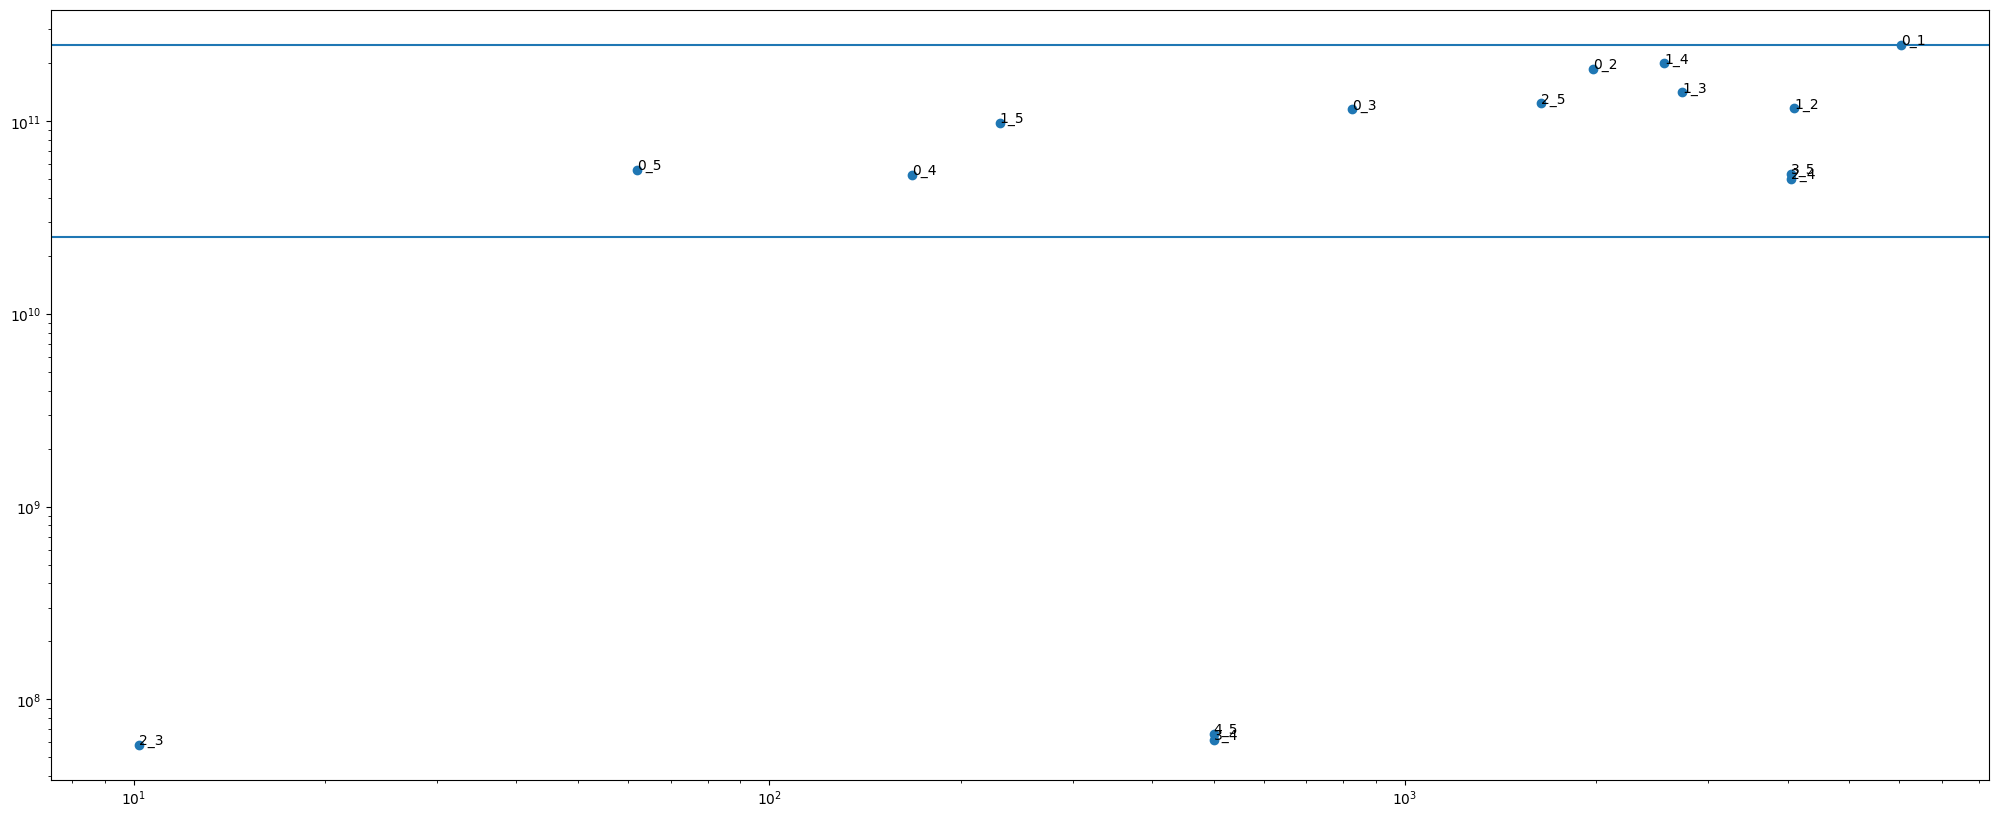

In [37]:
arith_intensity = [] #flops/bytes
flop_per_s = [] #flops/s
tags = []
for i in [1,2,3,4,5]:
    for rank in range(0,i):
        fname = f"/Users/animeshnd/model_splitting/logs/roofline/{i}_size/speed_chronos{rank}.log"
        time_map, last_iter = time_reader(fname)
        flop = time_map[1]["flop"]
        comp_t = time_map[1]["comp"]
        sent_b = time_map[1]["sent"]
        recv_b = time_map[1]["recv"]
        flop_per_s.append(flop/comp_t)
        arith_intensity.append(flop/(sent_b+recv_b))
        tags.append(f"{rank}_{i}")
        # print(fname)
        # print(time_map)
    #     break
    # break

fig, axs = plt.subplots(figsize=(25,10))
axs.scatter(arith_intensity, flop_per_s)
axs.axhline(y=flop_per_s[0])
axs.axhline(y=flop_per_s[0]*1/10) #pretending 10% range to theoretical max?
for r in range(len(arith_intensity)):
    axs.text(arith_intensity[r], flop_per_s[r], tags[r])
axs.loglog()


[]

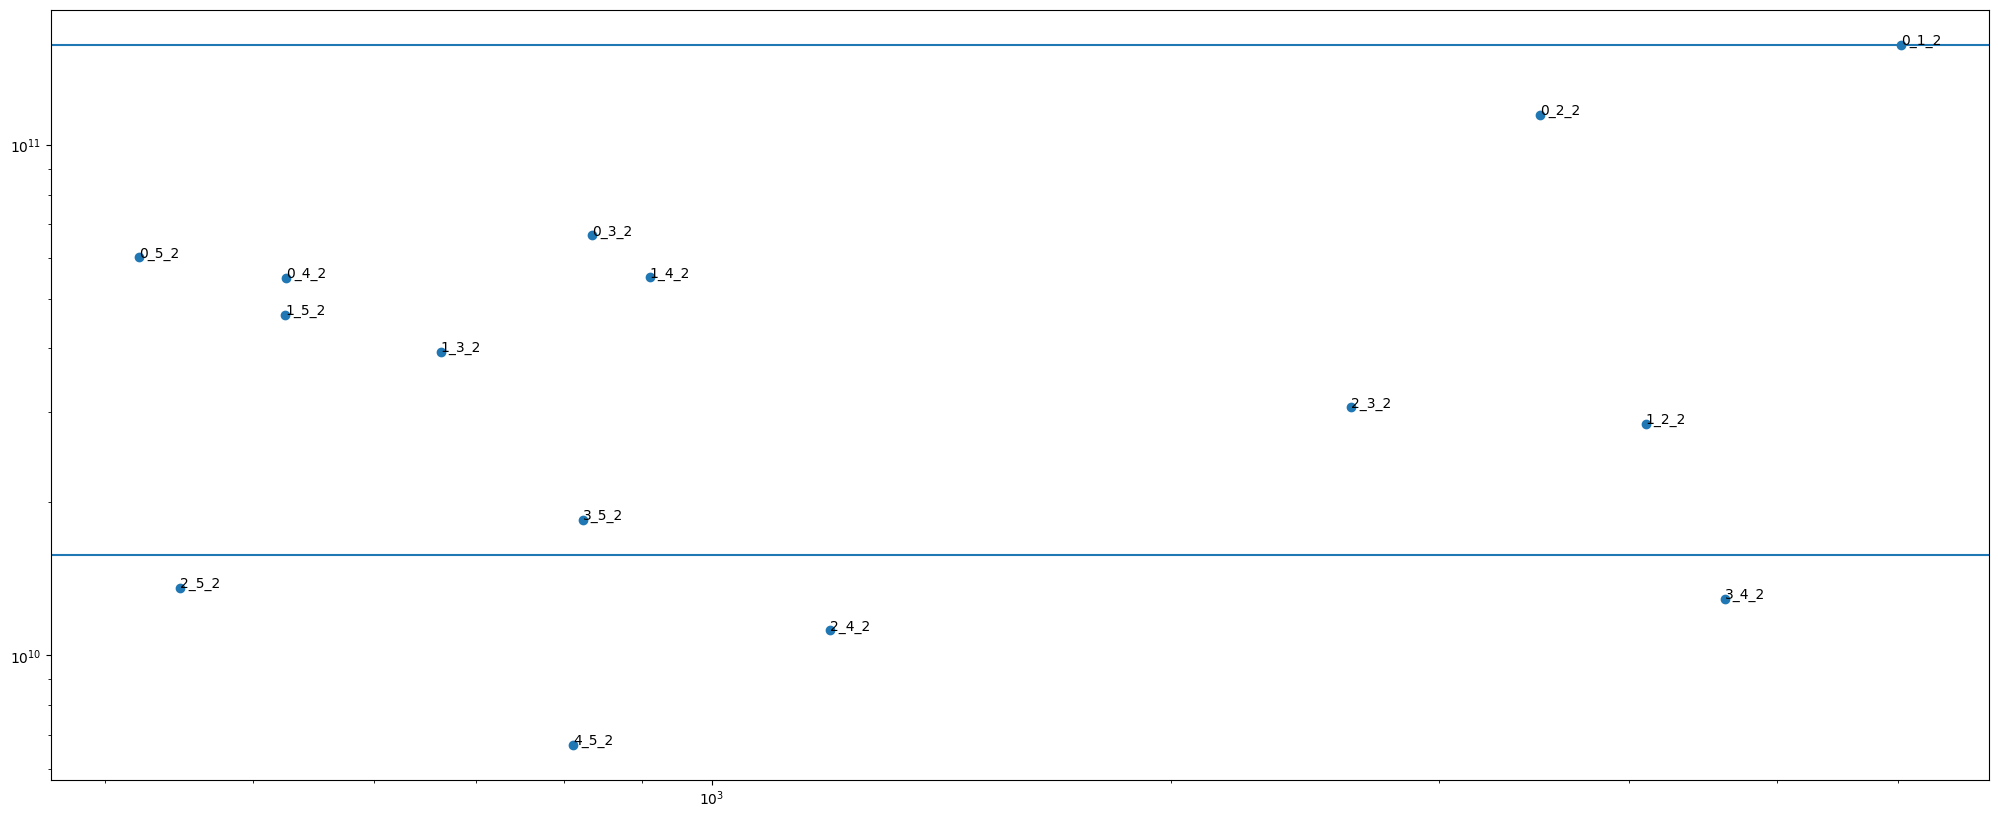

: 

In [52]:
arith_intensity = [] #flops/bytes
flop_per_s = [] #flops/s
tags = []
flops_per_batch = {}
for i in [1,2,3,4,5]:
    if i not in flops_per_batch:
        flops_per_batch[i] = {}
    for batch_size in [2]:#[2,4,6]:
        if batch_size not in flops_per_batch[i]:
            flops_per_batch[i][batch_size]={}
        for rank in range(0,i):
            # fname = f"/Users/animeshnd/model_splitting/logs/roofline/mb_smol/{i}_size/{batch_size}/speed_chronos{rank}.log"
            fname = f"/Users/animeshnd/model_splitting/logs/roofline/resnet_18/{i}_size/{batch_size}/speed_chronos{rank}.log"
            time_map, last_iter = time_reader(fname)
            flop = time_map[1]["flop"]
            comp_t = time_map[1]["comp"]
            sent_b = time_map[1]["sent"]
            recv_b = time_map[1]["recv"]
            flop_per_s.append(flop/comp_t)
            arith_intensity.append(flop/(sent_b+recv_b))
            tags.append(f"{rank}_{i}_{batch_size}")
            # print(fname)
            # print(time_map)
        #     break
        # break

fig, axs = plt.subplots(figsize=(25,10))
axs.scatter(arith_intensity, flop_per_s)
for i in flop_per_s[:1]:
    axs.axhline(y=i)
    axs.axhline(y=i*1/10) #pretending 10% range to theoretical max?
for r in range(len(arith_intensity)):
    axs.text(arith_intensity[r], flop_per_s[r], tags[r])
axs.loglog()
